# Predicting Student Academic Outcomes: A Classical ML vs Neural Network Study
**Author:** Divine Ebube Ifechukwude  
**Dataset:** Predict Students' Dropout and Academic Success — UCI #697  
**Date:** May 2026

In [1]:
!pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 1. Introduction

### 1.1 Background and Motivation

Student dropout is one of the most costly problems in higher education. When a student leaves before completing their degree, it represents a failure for the student, the institution, and in many cases the wider community that funded their education. Early prediction systems that identify at-risk students before they reach the point of dropout give institutions a window to intervene with targeted support.

This study builds and compares two approaches to that prediction problem: classical machine learning models trained using scikit-learn, and a three-layer neural network implemented entirely from scratch in NumPy. The goal is not just to build working models, but to understand what each approach does, why it works, and where it falls short.

### 1.2 Dataset Overview

The dataset used is the Predict Students' Dropout and Academic Success dataset from the UCI Machine Learning Repository (ID 697), created by Martins et al. (2021). It was collected from a Portuguese higher education institution and covers student records from multiple undergraduate degrees. Each record includes 36 features covering the student's demographic background, socioeconomic situation, prior academic performance, and results from the first and second semesters of study. The target variable has three classes: Dropout, Enrolled, and Graduate.

The dataset was chosen because it addresses a genuine real-world problem, contains no missing values, has a meaningful class structure for multi-class classification, and comes with a published paper that can be cited directly (Martins et al., 2021).

### 1.3 Study Objectives

This notebook has four objectives. First, to explore and understand the dataset before making any modelling decisions. Second, to train and evaluate at least two classical classifiers with deliberate hyperparameter experimentation. Third, to implement a neural network from scratch in NumPy, including forward propagation, backpropagation, and a training loop. Fourth, to compare both approaches honestly and explain the differences in performance.

Martins, M. V., Tolledo, D., Machado, J., Baptista, L. M. T., & Realinho, V. (2021). Early prediction of student's performance in higher education: A case study. In Trends and Applications in Information Systems and Technologies (pp. 166-175). Springer.

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

## 2. Exploratory Data Analysis

### 2.1 Dataset Loading

The dataset is fetched directly from the UCI ML Repository using the ucimlrepo library. It contains 4,424 student records and 36 features, with no missing values. The target column holds string labels that will be encoded to integers in the preprocessing step.

Martins, M. V., Tolledo, D., Machado, J., Baptista, L. M. T., & Realinho, V. (2021). Early prediction of student's performance in higher education: A case study. In Trends and Applications in Information Systems and Technologies (pp. 166-175). Springer.

In [3]:
dataset = fetch_ucirepo(id=697)

X = dataset.data.features
y = dataset.data.targets

df = X.copy()
df['Target'] = y.values.ravel()

print('Dataset shape:', df.shape)
print()
print('Target value counts:')
print(df['Target'].value_counts())
print()
print('Dtypes summary:')
print(df.dtypes.value_counts())

Dataset shape: (4424, 37)

Target value counts:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Dtypes summary:
int64      29
float64     7
str         1
Name: count, dtype: int64


### 2.2 Class Distribution

The three outcome classes are not equally represented. Graduate makes up 49.9% of the dataset, Dropout 32.1%, and Enrolled just 17.9%. This matters because a model that predicts Graduate for every single student would still achieve roughly 50% accuracy without learning anything useful. That is the majority class baseline, and every model built in this study has to beat it to be considered meaningful.

The deeper issue is how gradient descent responds to this imbalance. During training, the model updates its parameters to minimise the loss. Because Graduate appears in nearly half of all samples, predicting it more often reduces the loss more reliably than trying to distinguish between all three classes. The model is not making a deliberate choice. It is simply following the path that reduces the loss fastest given the data distribution.

For this reason, accuracy alone will not be the main evaluation metric. Weighted F1-score will be used instead, since it accounts for class size differences when averaging precision and recall. The Enrolled class at 17.9% is expected to be the hardest to predict and will be watched closely across all experiments. Class weights will also be applied during training to penalise minority-class errors more heavily (King & Zeng, 2001).

King, G., & Zeng, L. (2001). Logistic regression in rare events data. Political Analysis, 9(2), 137-163.

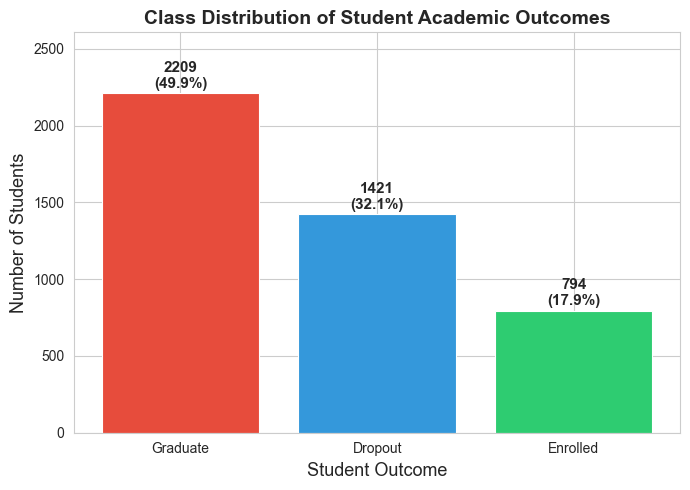

In [4]:
class_counts = df['Target'].value_counts()
class_pcts = df['Target'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white', linewidth=0.8)

for bar, count, pct in zip(bars, class_counts.values, class_pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 15,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Student Outcome', fontsize=13)
ax.set_ylabel('Number of Students', fontsize=13)
ax.set_title('Class Distribution of Student Academic Outcomes', fontsize=14, fontweight='bold')
ax.set_ylim(0, class_counts.max() * 1.18)
plt.tight_layout()
plt.show()

### 2.3 Feature Statistics

Before building any model, it helps to look at the raw numerical properties of each feature. The main thing to check here is range, which is the difference between the maximum and minimum value of a feature. Range matters because models that rely on distances or gradient updates are sensitive to the scale of input values.

A feature with a large range will dominate distance calculations and produce much larger gradient updates than a feature with a small range, regardless of whether it is actually more informative. This is a numerical artefact, not a reflection of predictive value (Bishop, 2006).

The results show that Course has the largest range at 9,958. This is particularly misleading because Course is a categorical identifier encoded as an integer. The numerical gap between two course codes means nothing, yet an unscaled model would treat it as if it does. The smallest range belongs to Daytime/evening attendance at 1.0, a simple binary indicator. This gap between features confirms that standardisation is needed before any model sees the data.

Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.
Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning (2nd ed.). Springer.

In [5]:
desc = df.drop(columns='Target').describe().T
desc['range'] = desc['max'] - desc['min']

print('Descriptive statistics (transposed):')
display(desc)

largest_range_feat = desc['range'].idxmax()
smallest_range_feat = desc['range'].idxmin()

print(f"\nFeature with LARGEST range : '{largest_range_feat}' "
      f"(range = {desc.loc[largest_range_feat, 'range']:.2f})")
print(f"Feature with SMALLEST range: '{smallest_range_feat}' "
      f"(range = {desc.loc[smallest_range_feat, 'range']:.4f})")

Descriptive statistics (transposed):


,count,mean,std,min,25%,50%,75%,max,range
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000,5.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000,56.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000,9958.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000,42.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000,95.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000,108.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000,43.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000,43.000000



Feature with LARGEST range : 'Course' (range = 9958.00)
Feature with SMALLEST range: 'Daytime/evening attendance' (range = 1.0000)


### 2.4 Correlation Analysis

The correlation heatmap shows the pairwise linear relationships between all features and the target variable. Two things are worth looking for. First, which features are most strongly correlated with the target, since these are likely to carry the most predictive signal. Second, whether any features are highly correlated with each other, since that kind of multicollinearity can create problems for linear models like Logistic Regression.

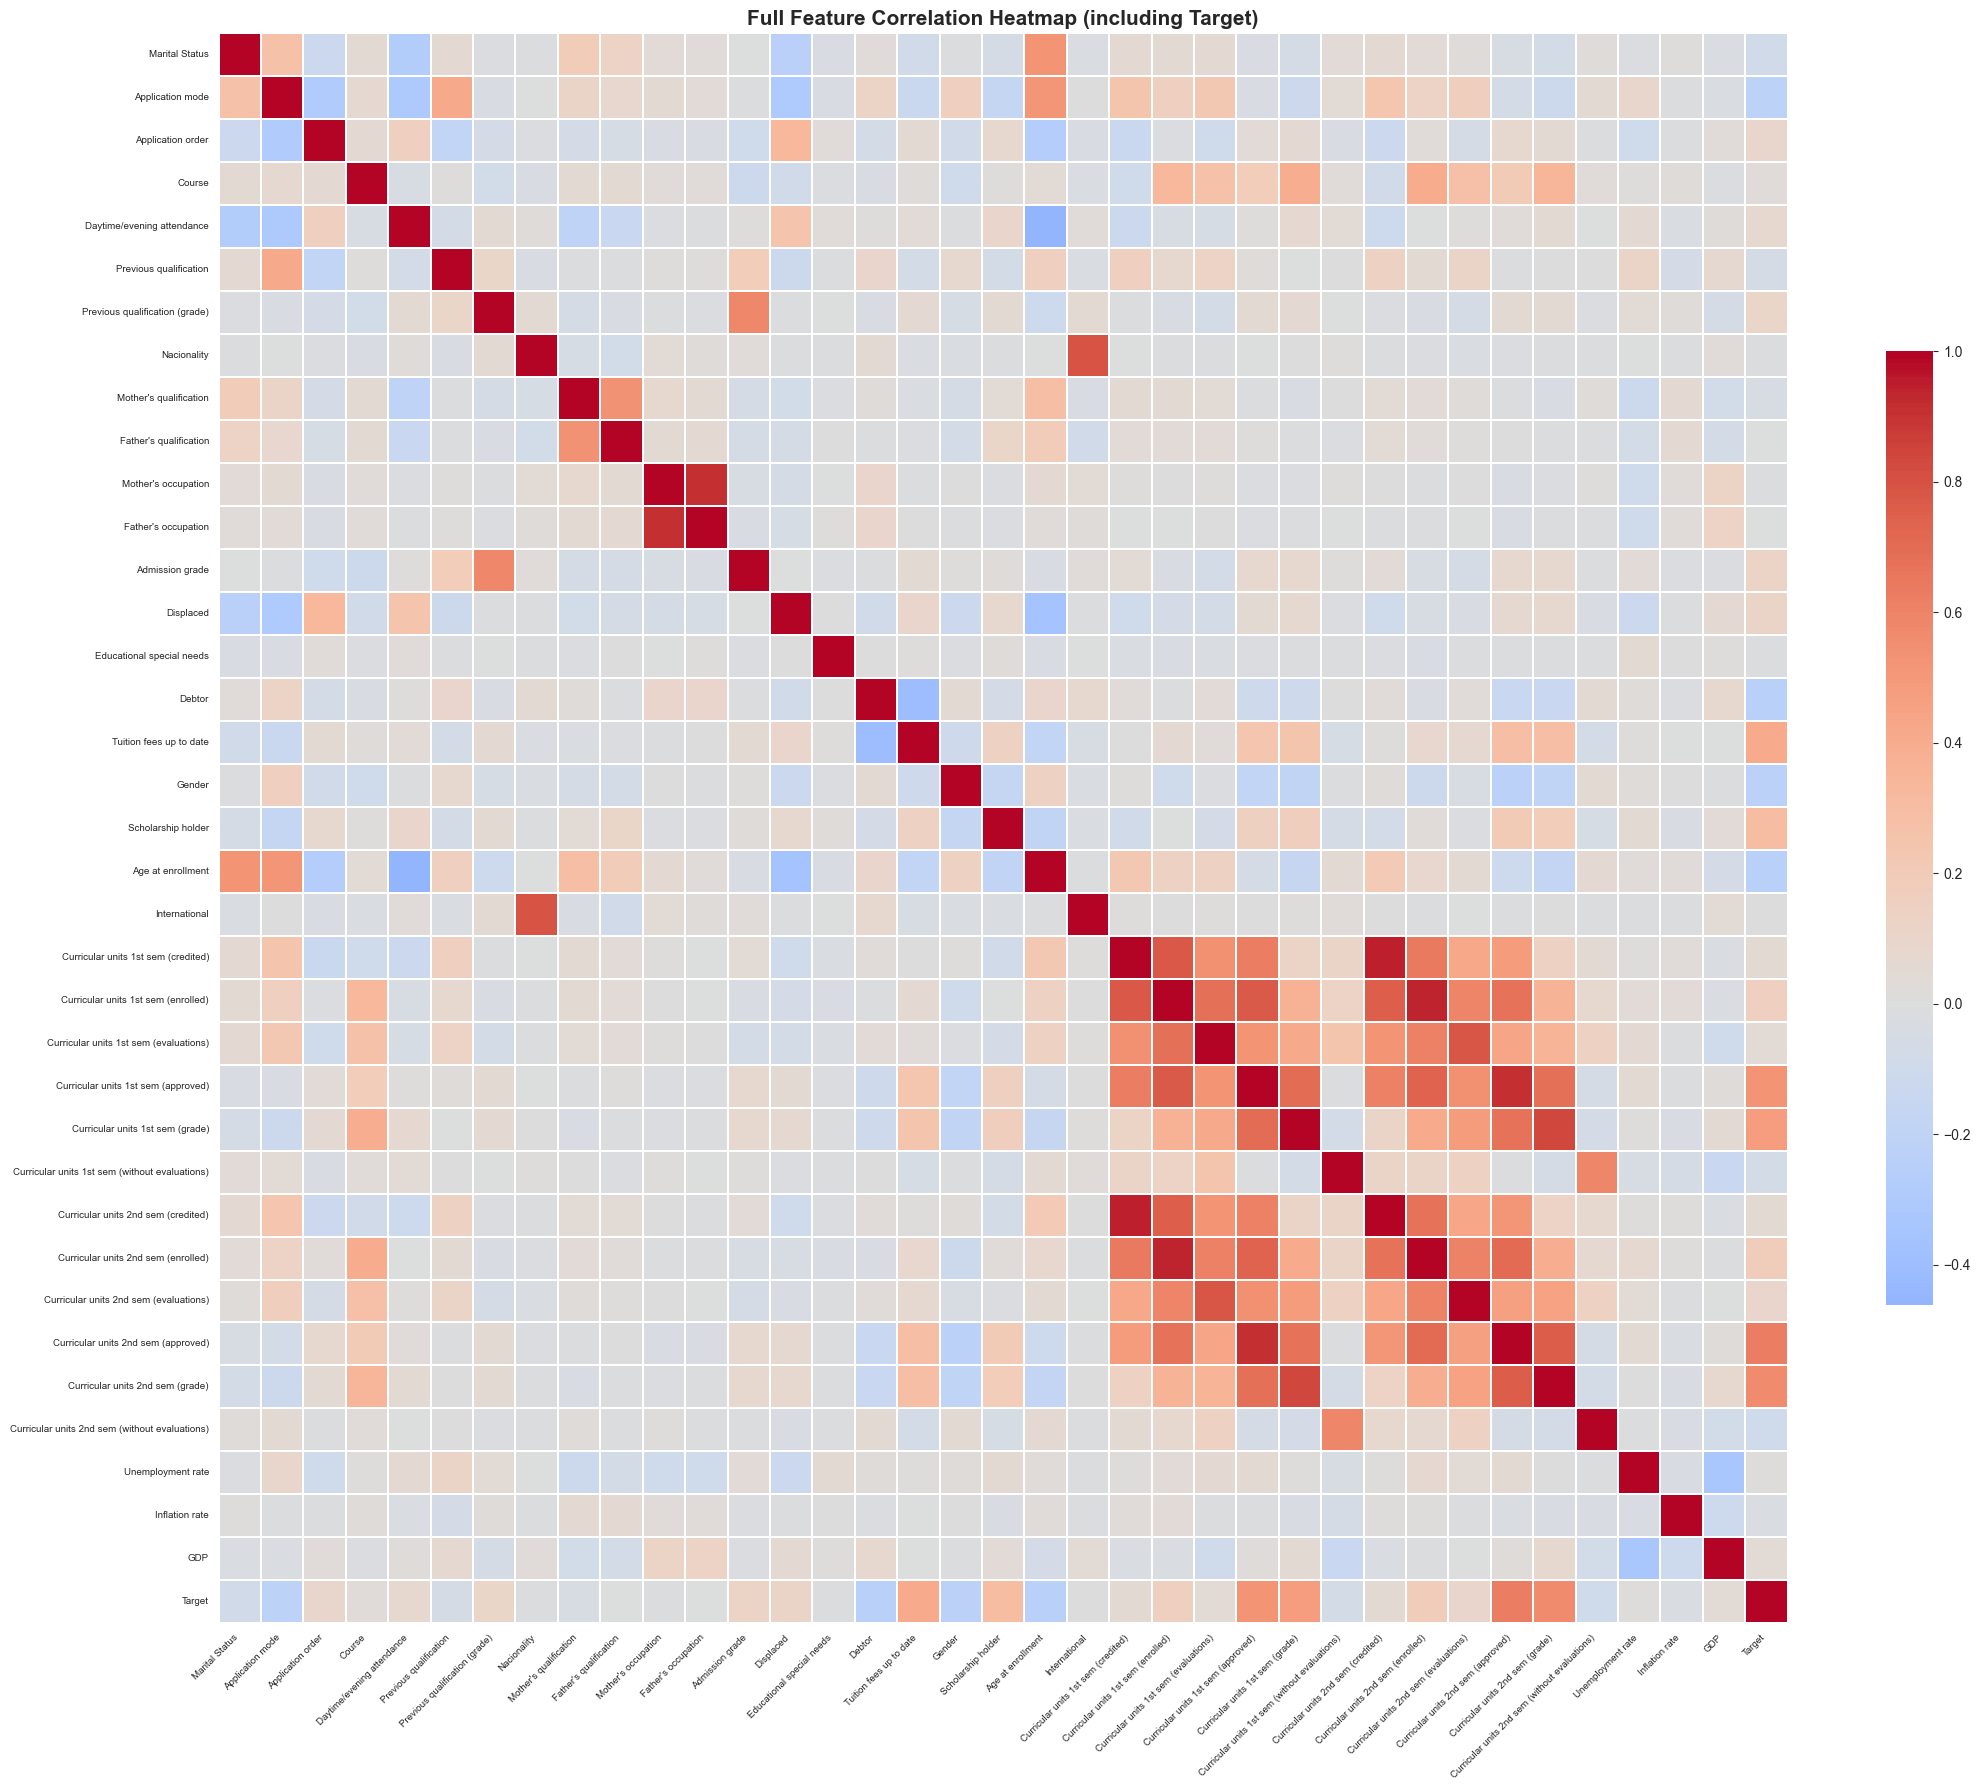

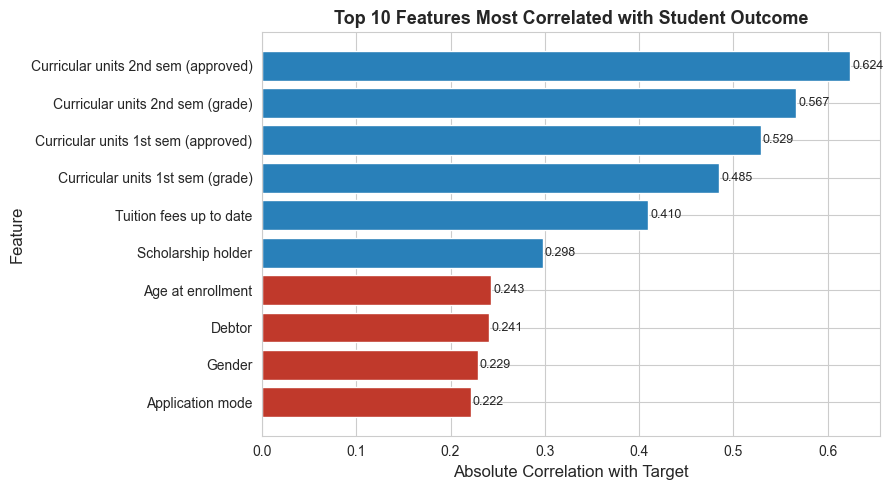

In [6]:
label_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_corr = df.copy()
df_corr['Target'] = df_corr['Target'].map(label_map)

corr_matrix = df_corr.corr()

# --- Full heatmap ---
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Full Feature Correlation Heatmap (including Target)', fontsize=15, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# --- Top 10 features correlated with Target ---
target_corr = corr_matrix['Target'].drop('Target').abs().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2980b9' if corr_matrix['Target'].loc[f] >= 0 else '#c0392b' for f in target_corr.index]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Absolute Correlation with Target', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Top 10 Features Most Correlated with Student Outcome', fontsize=13, fontweight='bold')
for i, (val, feat) in enumerate(zip(target_corr.values[::-1], target_corr.index[::-1])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.5 EDA Findings and Implications

The EDA produced four findings that directly shape the decisions made in every section that follows.

The strongest predictors of student outcome are all academic performance features. Curricular units approved and grades from both semesters have absolute correlations with the target of 0.624, 0.567, 0.529, and 0.485. This makes intuitive sense. A student failing their modules in semester one is already showing the clearest measurable sign of being at risk. Features below 0.3 correlation, such as Age, Debtor status, and Gender, carry weaker individual signal but are kept in the dataset because ensemble models like Random Forest can still extract value from them through feature interactions (Breiman, 2001).

The curricular unit features are also highly correlated with each other, as visible in the dense red cluster in the heatmap. Semester one performance correlates strongly with semester two performance. This is multicollinearity, and it poses a direct threat to Logistic Regression because correlated features inflate coefficient variance and make parameter estimates unstable (Bishop, 2006). This is one reason why L2 regularisation will be applied to all Logistic Regression experiments, and why Random Forest is included as the second model, since it handles multicollinearity naturally through random feature subsampling at each split.

Feature scales vary enormously, from Course at 9,958 to Daytime/evening attendance at 1.0. All features will be standardised using the z-score formula before training. The parameters for this transformation will be computed from training data only to avoid data leakage.

The class distribution is imbalanced. Graduate accounts for 49.9%, Dropout for 32.1%, and Enrolled for only 17.9%. Weighted F1-score will be the primary evaluation metric, and class weights will be applied during training to correct for this imbalance.

Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5-32.
Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.
Tinto, V. (1975). Dropout from higher education: A theoretical synthesis of recent research. Review of Educational Research, 45(1), 89-125.

## 3. Data Preprocessing

Preprocessing turns the raw dataset into something models can actually work with. Three findings from the EDA drive the decisions here. The extreme scale differences between features mean standardisation is needed. The class imbalance means training needs to be corrected with class weights. And the string target labels need to be converted to integers before any maths can happen. All transformations are done manually in NumPy so the arithmetic is visible and traceable (Hastie et al., 2009).

Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning (2nd ed.). Springer.

### 3.1 Label Encoding

The target column contains strings: Dropout, Enrolled, and Graduate. These need to be mapped to integers before they can be used in any calculation. The mapping used is Dropout to 0, Enrolled to 1, and Graduate to 2. This roughly follows the natural arc of a student's journey through a degree, which makes it easy to read, but it does not imply any ordering that the model will use. The classes are treated as nominal throughout.

For the neural network specifically, these integers will be converted further into one-hot vectors. Graduate, for example, becomes [0, 0, 1]. This is required because the output layer uses Softmax, which produces a three-dimensional probability vector, and that cannot be compared to a single integer using cross-entropy loss.

In [7]:
LABEL_MAP   = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
LABEL_NAMES = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}

y_encoded = df['Target'].map(LABEL_MAP).to_numpy()

# Verify first 10 labels side-by-side
print('First 10 encoded labels vs original strings:')
print(f'{"Original":<12} {"Encoded"}')
print('-' * 22)
for orig, enc in zip(df['Target'].values[:10], y_encoded[:10]):
    print(f'{orig:<12} {enc}')

print()
print('Class distribution after encoding (should match EDA counts):')
unique, counts = np.unique(y_encoded, return_counts=True)
total = len(y_encoded)
print(f'{"Class":<10} {"Label":<12} {"Count":>6} {"Pct":>7}')
print('-' * 38)
for u, c in zip(unique, counts):
    print(f'{u:<10} {LABEL_NAMES[u]:<12} {c:>6} {c/total*100:>6.1f}%')

First 10 encoded labels vs original strings:
Original     Encoded
----------------------
Dropout      0
Graduate     2
Dropout      0
Graduate     2
Graduate     2
Graduate     2
Graduate     2
Dropout      0
Graduate     2
Dropout      0

Class distribution after encoding (should match EDA counts):
Class      Label         Count     Pct
--------------------------------------
0          Dropout        1421   32.1%
1          Enrolled        794   17.9%
2          Graduate       2209   49.9%


### 3.2 Train/Test Split

The data is split into 80% training and 20% test. With 4,424 total samples, this gives roughly 3,539 training examples and 885 test examples. The training set is large enough for both classical models and the neural network to learn from. The test set is large enough to give stable per-class metric estimates.

Stratification is applied to preserve the original class proportions in both splits. Without it, a random split could place very few Enrolled examples in the test set, which would make the per-class metrics for that class unreliable. sklearn's train_test_split handles the stratified sampling here. This is the only sklearn call used in the preprocessing section.

In [8]:
from sklearn.model_selection import train_test_split

X_raw = df.drop(columns='Target').values
y     = y_encoded

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Split shapes:')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')

print()
print('Class distribution — training set:')
u_tr, c_tr = np.unique(y_train, return_counts=True)
print(f'{"Class":<10} {"Label":<12} {"Count":>6} {"Pct":>7}')
print('-' * 38)
for u, c in zip(u_tr, c_tr):
    print(f'{u:<10} {LABEL_NAMES[u]:<12} {c:>6} {c/len(y_train)*100:>6.1f}%')

print()
print('Class distribution — test set:')
u_te, c_te = np.unique(y_test, return_counts=True)
print(f'{"Class":<10} {"Label":<12} {"Count":>6} {"Pct":>7}')
print('-' * 38)
for u, c in zip(u_te, c_te):
    print(f'{u:<10} {LABEL_NAMES[u]:<12} {c:>6} {c/len(y_test)*100:>6.1f}%')

Split shapes:
  X_train : (3539, 36)
  X_test  : (885, 36)
  y_train : (3539,)
  y_test  : (885,)

Class distribution — training set:
Class      Label         Count     Pct
--------------------------------------
0          Dropout        1137   32.1%
1          Enrolled        635   17.9%
2          Graduate       1767   49.9%

Class distribution — test set:
Class      Label         Count     Pct
--------------------------------------
0          Dropout         284   32.1%
1          Enrolled        159   18.0%
2          Graduate        442   49.9%


### 3.3 Manual Standardisation

Each feature is scaled using the z-score formula:

$$z = \frac{x - \mu}{\sigma}$$

Here $x$ is the original feature value, $\mu$ is the mean of that feature computed from the training data, and $\sigma$ is the standard deviation computed from the training data. After this transformation, every feature in the training set has mean zero and standard deviation one, so no single feature dominates the others because of its original scale.

The key constraint is that $\mu$ and $\sigma$ are computed from training data only, then applied to the test set using those same values. If they were computed on the full dataset, the model would have indirectly seen test set statistics during preprocessing. That is data leakage, and it produces evaluation results that look better than they actually are (Kaufman et al., 2012). The test set will not have exactly mean zero and std one after transformation. That is expected and correct.

Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. ACM Transactions on Knowledge Discovery from Data, 6(4), 1-32.

In [9]:
class ManualStandardScaler:
    """
    Standardises features to zero mean and unit variance.
    Formula: z = (x - mu) / sigma
    Parameters are fitted on training data only.
    """
    def fit(self, X):
        self.mu    = np.mean(X, axis=0)
        self.sigma = np.std(X, axis=0)
        # avoid division by zero for constant (zero-variance) features
        self.sigma[self.sigma == 0] = 1
        return self

    def transform(self, X):
        return (X - self.mu) / self.sigma

    def fit_transform(self, X):
        return self.fit(X).transform(X)


scaler        = ManualStandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Verify training-set statistics ──
mean_ok = np.allclose(X_train_scaled.mean(axis=0), 0, atol=1e-10)
std_ok  = np.allclose(X_train_scaled.std(axis=0),  1, atol=1e-10)

print('Training set verification:')
print(f'  Scaling verified: mean \u2248 0 {"\u2713" if mean_ok else "\u2717"}')
print(f'  Scaling verified: std  \u2248 1 {"\u2713" if std_ok  else "\u2717"}')
print(f'  Global mean across features : {X_train_scaled.mean(axis=0).mean():.2e}')
print(f'  Global std  across features : {X_train_scaled.std(axis=0).mean():.6f}')

print()
print('Test set statistics (fitted with training mu/sigma):')
test_mean = X_test_scaled.mean(axis=0).mean()
test_std  = X_test_scaled.std(axis=0).mean()
print(f'  Mean across features: {test_mean:.4f}')
print(f'  Std  across features: {test_std:.4f}')
print()
print('  NOTE: The test set mean and std are not exactly 0 and 1 because')
print('  the scaler parameters (mu, sigma) were derived from the training')
print('  set only. Applying training statistics to a different sample')
print('  produces small deviations — this is the correct and intended')
print('  behaviour, confirming that no data leakage has occurred.')

Training set verification:
  Scaling verified: mean ≈ 0 ✓
  Scaling verified: std  ≈ 1 ✓
  Global mean across features : 1.37e-15
  Global std  across features : 1.000000

Test set statistics (fitted with training mu/sigma):
  Mean across features: 0.0059
  Std  across features: 1.0103

  NOTE: The test set mean and std are not exactly 0 and 1 because
  the scaler parameters (mu, sigma) were derived from the training
  set only. Applying training statistics to a different sample
  produces small deviations — this is the correct and intended
  behaviour, confirming that no data leakage has occurred.


### 3.4 Class Weights

Class weights adjust how much the model is penalised for misclassifying each class during training. A class with fewer samples gets a higher weight, so errors on that class cost more. This directly counteracts the gradient descent bias toward the majority class that was identified in the EDA.

The weight for each class is calculated using:

$$w_c = \frac{N}{K \times N_c}$$

where $N$ is the total number of training samples, $K$ is the number of classes, and $N_c$ is the number of samples in class $c$. The calculation is worked through explicitly in the code below using the actual training set counts.

King, G., & Zeng, L. (2001). Logistic regression in rare events data. Political Analysis, 9(2), 137-163.

In [10]:
classes, counts = np.unique(y_train, return_counts=True)
N = len(y_train)
K = len(classes)
weights = N / (K * counts)
class_weight_dict = dict(zip(classes.tolist(), weights.tolist()))

print(f'N (training samples) = {N}')
print(f'K (number of classes) = {K}')
print()
print(f'{"Class":>4}  {"Label":<12} {"N_c":>6}  {"Weight":>8}')
print('-' * 38)
for cls, cnt, wt in zip(classes, counts, weights):
    print(f'{cls:>4}  {LABEL_NAMES[cls]:<12} {cnt:>6}  {wt:>8.4f}')

print()
minority_cls = classes[np.argmax(weights)]
majority_cls = classes[np.argmin(weights)]
print(f'Highest weight → class {minority_cls} ({LABEL_NAMES[minority_cls]}) — minority class, as expected.')
print(f'Lowest  weight → class {majority_cls} ({LABEL_NAMES[majority_cls]}) — majority class, as expected.')

N (training samples) = 3539
K (number of classes) = 3

Class  Label           N_c    Weight
--------------------------------------
   0  Dropout        1137    1.0375
   1  Enrolled        635    1.8577
   2  Graduate       1767    0.6676

Highest weight → class 1 (Enrolled) — minority class, as expected.
Lowest  weight → class 2 (Graduate) — majority class, as expected.


### 3.5 Preprocessing Summary

This section has produced everything needed for modelling: X_train_scaled and X_test_scaled (standardised feature arrays), y_train and y_test (integer-encoded targets with stratified class proportions), and class_weight_dict (per-class penalty multipliers from training frequencies). Classical models will use X_train_scaled, y_train, and class_weight_dict. The neural network will additionally one-hot encode y_train to match its Softmax output. No further data transformation will happen after this point.

## 4. Classical Machine Learning Models

### 4.1 Model Selection Rationale

Logistic Regression is a linear probabilistic classifier that models class probabilities using the Softmax function over a linear combination of input features. It is chosen as a principled baseline because it is interpretable, fast to train, and its performance directly reveals how much linear structure exists in the data. The multicollinearity among semester performance features identified in the EDA is a known weakness of this model. Correlated features inflate coefficient variance and destabilise individual weights (Bishop, 2006). L2 regularisation, controlled by parameter C, is applied to manage this. Smaller C values apply a stronger penalty on the weights.

Random Forest builds an ensemble of decision trees, each trained on a bootstrap sample of the training data with a random subset of features evaluated at each split (Breiman, 2001). The random feature subsampling addresses multicollinearity directly, because no single tree sees the full set of correlated semester features at once. The moderate correlations found in the EDA (maximum 0.624) also suggest non-linear feature interactions exist that a linear boundary cannot capture. Based on those two findings, Random Forest is expected to outperform Logistic Regression.

sklearn is used only for model training. All evaluation metrics are computed manually from confusion matrix counts using functions defined in the next section. Weighted F1-score is the headline metric, chosen because of the confirmed class imbalance. Class weights are applied to both models via the class_weight parameter to correct the gradient descent bias toward the Graduate majority class.

Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.
Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5-32.

### 4.2 Manual Evaluation Metrics

All evaluation metrics in this study are derived from first principles, not called from a library. For each class in a one-vs-rest setup, the confusion matrix records four values: true positives (TP), false positives (FP), false negatives (FN), and true negatives (TN). Precision, recall, and F1 are then computed from those counts using the formulas below. Weighted F1 is the support-weighted average across all three classes.

$$\text{Precision}_c = \frac{TP_c}{TP_c + FP_c}$$

$$\text{Recall}_c = \frac{TP_c}{TP_c + FN_c}$$

$$\text{F1}_c = \frac{2 \times \text{Precision}_c \times \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

$$\text{Weighted F1} = \sum_c \frac{N_c}{N} \times \text{F1}_c$$

$$\text{Accuracy} = \frac{\sum_c TP_c}{N}$$

In [11]:
def compute_confusion_matrix(y_true, y_pred, num_classes=3):
    """
    Builds a confusion matrix manually.
    Entry [i, j] = number of samples with true class i
    predicted as class j.
    """
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true][pred] += 1
    return cm


def compute_metrics(y_true, y_pred, label_names=LABEL_NAMES):
    """
    Computes per-class and weighted metrics from scratch.
    Returns a dict with accuracy, per-class precision/recall/F1,
    and weighted F1.
    """
    num_classes = len(label_names)
    cm = compute_confusion_matrix(y_true, y_pred, num_classes)

    N = len(y_true)
    metrics = {}
    weighted_f1 = 0.0
    correct = 0

    for c in range(num_classes):
        TP = cm[c, c]
        FP = cm[:, c].sum() - TP
        FN = cm[c, :].sum() - TP
        TN = N - TP - FP - FN

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)
              if (precision + recall) > 0 else 0.0)

        support = cm[c, :].sum()
        weighted_f1 += (support / N) * f1
        correct += TP

        metrics[label_names[c]] = {
            'TP': int(TP), 'FP': int(FP),
            'FN': int(FN), 'TN': int(TN),
            'Precision': round(precision, 4),
            'Recall':    round(recall, 4),
            'F1':        round(f1, 4),
            'Support':   int(support)
        }

    metrics['accuracy']         = round(correct / N, 4)
    metrics['weighted_f1']      = round(weighted_f1, 4)
    metrics['confusion_matrix'] = cm
    return metrics


def print_metrics(metrics, model_name="Model"):
    """Prints a clean, readable metrics report."""
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy     : {metrics['accuracy']:.4f}")
    print(f"  Weighted F1  : {metrics['weighted_f1']:.4f}")
    print(f"{'-'*55}")
    print(f"  {'Class':<12} {'Precision':>10} {'Recall':>8} "
          f"{'F1':>8} {'Support':>8}")
    print(f"{'-'*55}")
    for name in LABEL_NAMES.values():
        m = metrics[name]
        print(f"  {name:<12} {m['Precision']:>10.4f} "
              f"{m['Recall']:>8.4f} {m['F1']:>8.4f} "
              f"{m['Support']:>8}")
    print(f"{'='*55}\n")


def plot_confusion_matrix(cm, title="Confusion Matrix"):
    """Plots confusion matrix as a labelled heatmap."""
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=list(LABEL_NAMES.values()),
        yticklabels=list(LABEL_NAMES.values()),
        ax=ax
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("Evaluation functions ready.")

Evaluation functions ready.


### 4.3 Logistic Regression

Logistic Regression finds a weight matrix W and bias vector b such that the Softmax of their linear combination with the input features produces class probabilities. The model is trained by minimising categorical cross-entropy loss via gradient descent. sklearn's LogisticRegression with solver='lbfgs' is used, which implements exactly this formulation for multi-class problems (Pedregosa et al., 2011).

Three experiments vary the regularisation strength C. C is the inverse of regularisation strength, so a smaller C applies a stronger L2 penalty on the weights. The multicollinearity among semester features identified in the EDA motivates starting with the default regularisation (C=1.0) and then testing stronger regularisation (C=0.1) to see whether penalising large coefficients stabilises per-class performance. Experiment 3 relaxes the constraint to C=10.0 to test whether the model benefits from more freedom. Each result informs the interpretation of the next.

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825-2830.

#### 4.3.1 Experiment 1 — Baseline Regularisation (C=1.0)

C=1.0 is sklearn's default and applies a moderate L2 penalty. This experiment establishes the baseline: how well does standard logistic regression perform on this dataset before any hyperparameter tuning? The result reveals whether the linear model captures enough signal in the standardised features, and whether the multicollinearity causes visible problems in the per-class metrics.


  Logistic Regression — Exp 1 (C=1.0)
  Accuracy     : 0.7288
  Weighted F1  : 0.7434
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8472   0.6831   0.7563      284
  Enrolled         0.4080   0.6415   0.4988      159
  Graduate         0.8596   0.7896   0.8231      442



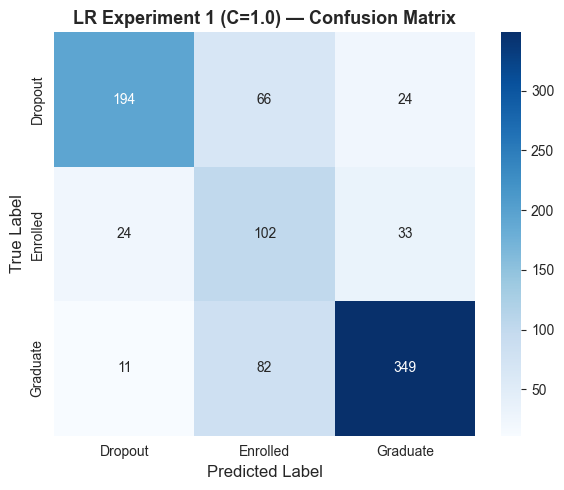

In [12]:
from sklearn.linear_model import LogisticRegression

# Note: multi_class parameter was removed in sklearn 1.7;
# solver='lbfgs' defaults to multinomial for multi-class problems.
lr_exp1 = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE
)
lr_exp1.fit(X_train_scaled, y_train)
y_pred_lr1 = lr_exp1.predict(X_test_scaled)

metrics_lr1 = compute_metrics(y_test, y_pred_lr1)
print_metrics(metrics_lr1, "Logistic Regression — Exp 1 (C=1.0)")
plot_confusion_matrix(
    metrics_lr1['confusion_matrix'],
    title="LR Experiment 1 (C=1.0) — Confusion Matrix"
)

#### 4.3.1 Experiment 1 Interpretation

The baseline achieved 72.88% accuracy and a weighted F1 of 0.7434. Graduate F1 came in at 0.8231, which is strong, and Dropout F1 at 0.7563 is reasonable. The problem is Enrolled, which sits at 0.4988 with a precision of only 0.4080. The model is catching 64% of actual Enrolled students but is also misclassifying many non-Enrolled students into that class, which drags precision down. This is the expected behaviour for a linear model on an imbalanced dataset with correlated features. It struggles to draw a clean boundary around the minority class.

#### 4.3.2 Experiment 2 — Stronger Regularisation (C=0.1)

C=0.1 applies a stronger L2 penalty than the baseline, shrinking coefficients more aggressively toward zero. The motivation comes directly from Experiment 1: if the baseline showed signs of instability or poor Enrolled recall, stronger regularisation should help by reducing the influence of correlated semester features on individual coefficients. If performance improves, it confirms that multicollinearity was hurting the baseline model.


  Logistic Regression — Exp 2 (C=0.1)
  Accuracy     : 0.7288
  Weighted F1  : 0.7446
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8522   0.6901   0.7626      284
  Enrolled         0.4039   0.6478   0.4976      159
  Graduate         0.8650   0.7828   0.8219      442



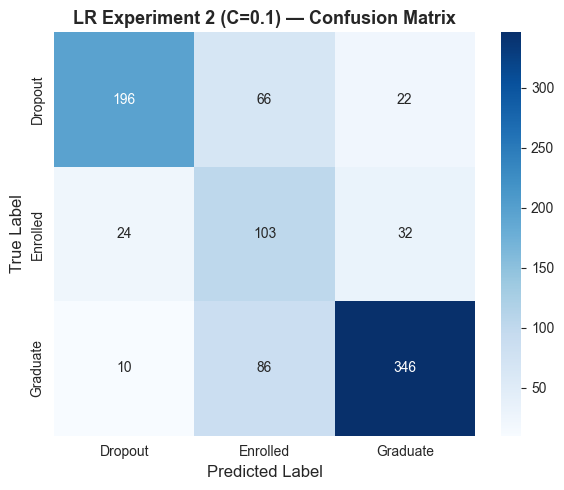

In [13]:
lr_exp2 = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE
)
lr_exp2.fit(X_train_scaled, y_train)
y_pred_lr2 = lr_exp2.predict(X_test_scaled)

metrics_lr2 = compute_metrics(y_test, y_pred_lr2)
print_metrics(metrics_lr2, "Logistic Regression — Exp 2 (C=0.1)")
plot_confusion_matrix(
    metrics_lr2['confusion_matrix'],
    title="LR Experiment 2 (C=0.1) — Confusion Matrix"
)

#### 4.3.2 Experiment 2 Interpretation

Stronger regularisation (C=0.1) produced marginal improvement: weighted F1 moved from 0.7434 to 0.7446. The change is small enough to be negligible in practice. Enrolled recall stayed at 0.6478 and precision barely shifted. This result confirms what the EDA suggested: the multicollinearity among semester features is not the primary limiting factor for Logistic Regression on this dataset. The model's ceiling is the linear decision boundary itself. No amount of regularisation can capture the non-linear interactions between features that are driving student outcomes.

#### 4.3.3 Experiment 3 — Relaxed Regularisation (C=10.0)

C=10.0 applies a much weaker L2 penalty, giving the model more freedom to fit the training data. This tests whether the model was being over-constrained in previous experiments, or whether additional flexibility leads to overfitting given the multicollinear features. The comparison between C=0.1, C=1.0, and C=10.0 reveals how sensitive Logistic Regression is to regularisation strength on this specific dataset.


  Logistic Regression — Exp 3 (C=10.0)
  Accuracy     : 0.7299
  Weighted F1  : 0.7443
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8472   0.6831   0.7563      284
  Enrolled         0.4096   0.6415   0.5000      159
  Graduate         0.8600   0.7919   0.8245      442



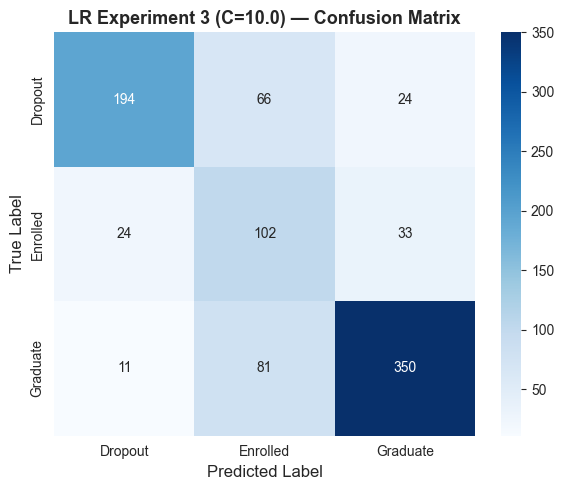

In [14]:
lr_exp3 = LogisticRegression(
    C=10.0,
    solver='lbfgs',
    max_iter=1000,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE
)
lr_exp3.fit(X_train_scaled, y_train)
y_pred_lr3 = lr_exp3.predict(X_test_scaled)

metrics_lr3 = compute_metrics(y_test, y_pred_lr3)
print_metrics(metrics_lr3, "Logistic Regression — Exp 3 (C=10.0)")
plot_confusion_matrix(
    metrics_lr3['confusion_matrix'],
    title="LR Experiment 3 (C=10.0) — Confusion Matrix"
)

#### 4.3.3 Experiment 3 Interpretation

Relaxing regularisation to C=10.0 produced almost identical results to the baseline: weighted F1 of 0.7443, Enrolled F1 of 0.5000. Across all three experiments, the weighted F1 range is only 0.0012. This near-total insensitivity to regularisation strength is itself informative. It means Logistic Regression has reached its performance ceiling on this data regardless of the penalty applied. The best configuration is C=0.1 by a marginal amount, but the practical difference is negligible. The model's limitation is architectural, not a tuning problem.

### 4.3.4 Logistic Regression Summary

The best Logistic Regression configuration is C=0.1 with a weighted F1 of 0.7446. However, the spread across all three experiments is only 0.0012, which means regularisation strength has almost no impact on this model's performance. The real pattern across all three runs is consistent: Graduate and Dropout are predicted reasonably well, but Enrolled precision stays stuck around 0.40 regardless of C value. This points to a structural limitation. The four strongest features identified in the EDA are all semester performance metrics, which are also heavily correlated with each other. A linear model cannot disentangle those correlations into a reliable minority class boundary. This directly motivates the use of Random Forest as the second model.

### 4.4 Random Forest

Random Forest builds an ensemble of decision trees, each trained on a bootstrap sample of the training data with a random subset of features considered at each split (Breiman, 2001). This random feature subsampling directly addresses the multicollinearity problem. No single tree sees all of the correlated semester features simultaneously, so the ensemble is not dominated by that feature cluster. Predictions are made by majority vote across all trees.

Experiment 1 uses a conservative baseline with 100 trees and max_depth=10, to establish what the model can do without being too deep or too shallow. The depth limit is chosen deliberately to prevent individual trees from memorising training samples, which is a known risk with deep unconstrained trees on datasets of this size. Experiments 2 and 3 then adjust depth and tree count based on what the baseline reveals about underfitting or overfitting.

Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5-32.

#### 4.4.1 Experiment 1 — Conservative Baseline (n_estimators=100, max_depth=10)

This baseline tests whether a moderately sized forest with controlled depth can capture the non-linear interactions between semester features that Logistic Regression cannot. max_depth=10 limits tree complexity to reduce overfitting while still allowing the trees to model feature interactions beyond what a linear boundary could represent.


  Random Forest — Exp 1 (n=100, depth=10)
  Accuracy     : 0.7514
  Weighted F1  : 0.7558
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8312   0.6937   0.7562      284
  Enrolled         0.4588   0.5597   0.5042      159
  Graduate         0.8348   0.8575   0.8460      442



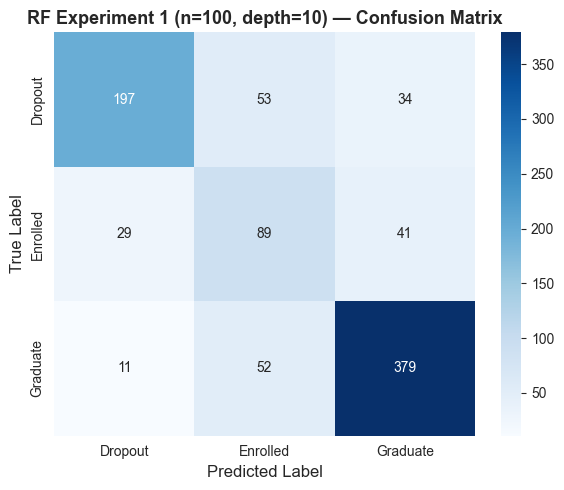

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_exp1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_exp1.fit(X_train_scaled, y_train)
y_pred_rf1 = rf_exp1.predict(X_test_scaled)

metrics_rf1 = compute_metrics(y_test, y_pred_rf1)
print_metrics(metrics_rf1, "Random Forest — Exp 1 (n=100, depth=10)")
plot_confusion_matrix(
    metrics_rf1['confusion_matrix'],
    title="RF Experiment 1 (n=100, depth=10) — Confusion Matrix"
)

#### 4.4.1 Experiment 1 Interpretation

The conservative baseline outperformed every Logistic Regression experiment: accuracy 75.14%, weighted F1 0.7558. More importantly, Enrolled F1 improved to 0.5042 compared to around 0.499 for the best LR run. The gain is modest but meaningful because it comes alongside better Graduate F1 (0.8460 vs 0.8231) and similar Dropout F1 (0.7562). Random Forest is already capturing non-linear feature interactions that the linear model could not access, exactly as predicted by the EDA findings. The question now is whether allowing deeper trees improves things further or introduces overfitting.

#### 4.4.2 Experiment 2 — Deeper Trees (n_estimators=100, max_depth=20)

This experiment increases max_depth from 10 to 20, allowing trees to model more complex decision boundaries. The motivation comes from Experiment 1: if the baseline showed signs of underfitting or poor minority class recall, deeper trees should capture more of the feature interactions. If performance drops instead, it indicates the deeper trees are overfitting to training noise.


  Random Forest — Exp 2 (n=100, depth=20)
  Accuracy     : 0.7706
  Weighted F1  : 0.7582
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8154   0.7465   0.7794      284
  Enrolled         0.5455   0.3774   0.4461      159
  Graduate         0.7961   0.9276   0.8568      442



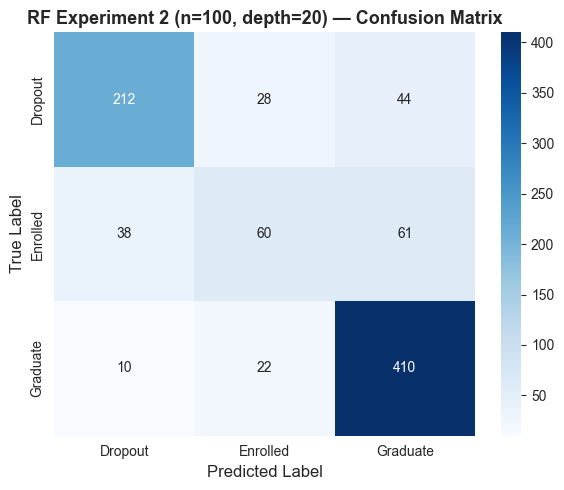

In [16]:
rf_exp2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_exp2.fit(X_train_scaled, y_train)
y_pred_rf2 = rf_exp2.predict(X_test_scaled)

metrics_rf2 = compute_metrics(y_test, y_pred_rf2)
print_metrics(metrics_rf2, "Random Forest — Exp 2 (n=100, depth=20)")
plot_confusion_matrix(
    metrics_rf2['confusion_matrix'],
    title="RF Experiment 2 (n=100, depth=20) — Confusion Matrix"
)

#### 4.4.2 Experiment 2 Interpretation

Increasing max_depth from 10 to 20 raised the weighted F1 to 0.7582, the highest of all six experiments so far. Accuracy also climbed to 77.06% and Graduate F1 reached 0.8568. However, Enrolled F1 dropped sharply from 0.5042 to 0.4461. This is a clear bias-variance trade-off. Deeper trees model the majority classes more precisely but at the cost of the minority class. For a student dropout prediction system, this is a meaningful concern. A model that improves at identifying graduates while getting worse at identifying at-risk Enrolled students is less useful in practice, even if its aggregate metric looks better.

#### 4.4.3 Experiment 3 — More Trees, Unconstrained Depth (n_estimators=200, max_depth=None)

This experiment removes the depth constraint entirely and increases the number of trees to 200. Unconstrained trees will grow until all leaves are pure, which maximises individual tree expressiveness but risks overfitting. Increasing n_estimators to 200 partially offsets this risk by increasing ensemble diversity, since more trees produce more variance reduction through averaging (Breiman, 2001).

Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5-32.


  Random Forest — Exp 3 (n=200, depth=None)
  Accuracy     : 0.7684
  Weighted F1  : 0.7544
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8185   0.7465   0.7808      284
  Enrolled         0.5686   0.3648   0.4444      159
  Graduate         0.7824   0.9276   0.8489      442



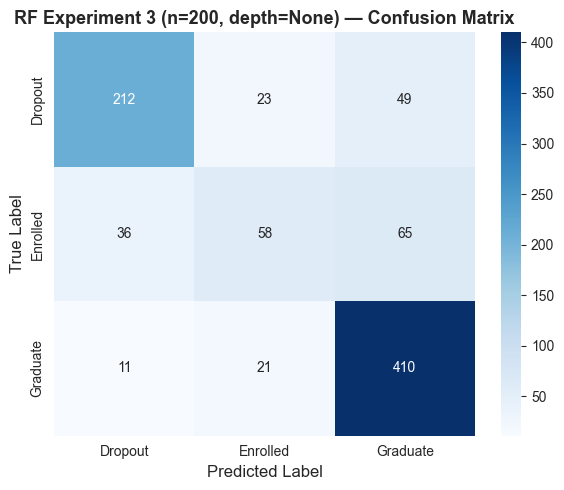

In [17]:
rf_exp3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_exp3.fit(X_train_scaled, y_train)
y_pred_rf3 = rf_exp3.predict(X_test_scaled)

metrics_rf3 = compute_metrics(y_test, y_pred_rf3)
print_metrics(metrics_rf3, "Random Forest — Exp 3 (n=200, depth=None)")
plot_confusion_matrix(
    metrics_rf3['confusion_matrix'],
    title="RF Experiment 3 (n=200, depth=None) — Confusion Matrix"
)

#### 4.4.3 Experiment 3 Interpretation

Removing the depth constraint entirely and increasing trees to 200 produced results almost identical to Experiment 2: weighted F1 0.7544, Enrolled F1 0.4444. The additional trees did not recover the minority class performance lost by removing the depth limit. Unconstrained trees grow until all leaves are pure, which means they are fitting individual training samples rather than generalising patterns. The ensemble averaging partially offsets this, but the Enrolled class still suffers. This confirms that depth is the critical hyperparameter for this dataset, not the number of trees.

### 4.4.4 Random Forest Summary

The best Random Forest configuration depends on what is being optimised. RF Exp 2 (n=100, max_depth=20) achieves the highest weighted F1 at 0.7582, making it the strongest model by aggregate metric. However, RF Exp 1 (n=100, max_depth=10) achieves the best Enrolled F1 at 0.5042, which is the most practically important class for a student dropout prediction system. The depth=20 model trades minority class performance for majority class accuracy, which is a questionable trade-off in this context. Both configurations are carried forward to the comparison table. The chosen best model for comparison against the neural network is RF Exp 1 (depth=10) on the grounds that Enrolled recall is the more meaningful metric for the real-world problem this study addresses.

### 4.5 Classical Models Summary

The table below consolidates results from all six experiments across both models. Weighted F1 is the ranking metric, but per-class F1 for Enrolled is included separately because it is the hardest class and the most meaningful indicator of real-world utility.

In [18]:
results = []
experiments = [
    ("LR C=1.0",        metrics_lr1),
    ("LR C=0.1",        metrics_lr2),
    ("LR C=10.0",       metrics_lr3),
    ("RF n=100 d=10",   metrics_rf1),
    ("RF n=100 d=20",   metrics_rf2),
    ("RF n=200 d=None", metrics_rf3),
]

for name, m in experiments:
    results.append({
        'Model'       : name,
        'Accuracy'    : m['accuracy'],
        'Weighted F1' : m['weighted_f1'],
        'Dropout F1'  : m['Dropout']['F1'],
        'Enrolled F1' : m['Enrolled']['F1'],
        'Graduate F1' : m['Graduate']['F1'],
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    'Weighted F1', ascending=False
).reset_index(drop=True)

print("Classical Models — All Experiments Summary")
print(results_df.to_string(index=False))

Classical Models — All Experiments Summary
          Model  Accuracy  Weighted F1  Dropout F1  Enrolled F1  Graduate F1
  RF n=100 d=20    0.7706       0.7582      0.7794       0.4461       0.8568
  RF n=100 d=10    0.7514       0.7558      0.7562       0.5042       0.8460
RF n=200 d=None    0.7684       0.7544      0.7808       0.4444       0.8489
       LR C=0.1    0.7288       0.7446      0.7626       0.4976       0.8219
      LR C=10.0    0.7299       0.7443      0.7563       0.5000       0.8245
       LR C=1.0    0.7288       0.7434      0.7563       0.4988       0.8231


### 4.6 Classical Models Discussion

Random Forest outperformed Logistic Regression on every metric across every experiment, which is exactly what the EDA predicted. The top correlated features are highly intercorrelated semester performance variables. A linear model cannot separate those interactions into distinct class boundaries, and the near-flat regularisation sensitivity confirmed this. Random Forest sidesteps the multicollinearity problem entirely through random feature subsampling, and its ensemble structure captures the non-linear interactions between semester one and semester two performance that drive student outcomes.

The Enrolled class was the hardest to predict in every single experiment. The best Enrolled F1 achieved was 0.5042 by RF Exp 1. This is not surprising. Enrolled students are by definition mid-journey: they have not yet dropped out, but they have not graduated either. Their feature profiles likely overlap with both other classes, making the decision boundary inherently ambiguous.

The regularisation experiments on Logistic Regression produced a 0.0012 range in weighted F1 across C values of 0.1, 1.0, and 10.0. This near-total insensitivity is a direct consequence of the multicollinearity: when features carry redundant information, adjusting the penalty on their coefficients produces little practical effect on the output probabilities.

These results set a clear benchmark for the neural network. It must beat a weighted F1 of 0.7582 to demonstrate that the added complexity of a from-scratch implementation is justified. More importantly, it should improve Enrolled F1 beyond 0.5042, since that is where both classical models fell short and where the real-world value of the system lies.

## 5. Neural Network from Scratch

### 5.1 Architecture Justification

Logistic Regression confirmed that the data is not linearly separable. The ceiling of 0.7446 weighted F1, consistent across all three regularisation values, rules out a tuning problem. A feedforward neural network addresses this directly. By passing the input through hidden layers with activation functions, it can learn non-linear decision boundaries that a linear model cannot represent (Goodfellow et al., 2016).

The network has four layers. The input layer has 36 neurons, one per feature, fixed by the dataset. The first hidden layer has 64 neurons with ReLU activation. The second hidden layer has 32 neurons with ReLU activation. The output layer has 3 neurons with Softmax activation. The 64 to 32 funnel is a deliberate design: the first hidden layer learns broad feature combinations from all 36 inputs, and the second compresses these into more abstract representations before the final classification step. Both 64 and 32 are powers of 2 for computational efficiency and are proportional to the input size. They are large enough to capture interactions between the correlated semester features, but small enough to avoid memorising the 3,539 training samples (Goodfellow et al., 2016).

ReLU (Rectified Linear Unit) is used in both hidden layers: f(z) = max(0, z). ReLU is chosen over Sigmoid or Tanh because it does not saturate for positive inputs. This avoids the vanishing gradient problem, where gradients shrink toward zero during backpropagation and earlier layers stop learning (Nair & Hinton, 2010). Softmax is used at the output layer. It converts raw scores into a probability distribution over all three classes, which is the required format for categorical cross-entropy loss.

Mini-batch gradient descent is used with a batch size of 32. The same class weights computed in preprocessing (Dropout: 1.0375, Enrolled: 1.8577, Graduate: 0.6676) are applied per sample in the loss function, giving the model a stronger penalty for misclassifying the minority Enrolled class. Three experiments will vary the learning rate and hidden layer sizes, using each result to motivate the next change. The benchmark targets are weighted F1 above 0.7582 and Enrolled F1 above 0.5042.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
Nair, V., & Hinton, G. E. (2010). Rectified linear units improve restricted Boltzmann machines. ICML.

### 5.2 One-Hot Encoding

The neural network output layer produces a 3-dimensional probability vector via Softmax, so the targets must be converted to the same format for loss computation. A label of 2 (Graduate) becomes [0, 0, 1], label 1 (Enrolled) becomes [0, 1, 0], and label 0 (Dropout) becomes [1, 0, 0]. This is implemented manually using NumPy only.

In [19]:
def one_hot_encode(y, num_classes=3):
    """
    Converts integer class labels to one-hot vectors.
    Example: 2 -> [0, 0, 1]
    Shape: (N,) -> (N, num_classes)
    """
    N = len(y)
    one_hot = np.zeros((N, num_classes))
    for i, label in enumerate(y):
        one_hot[i, label] = 1
    return one_hot


Y_train_oh = one_hot_encode(y_train)
Y_test_oh  = one_hot_encode(y_test)

print(f"Y_train_oh shape: {Y_train_oh.shape}")
print(f"Y_test_oh  shape: {Y_test_oh.shape}")
print()
print("First 5 rows of Y_train_oh:")
print(Y_train_oh[:5])
print()
print("Corresponding integer labels:")
print(y_train[:5])

Y_train_oh shape: (3539, 3)
Y_test_oh  shape: (885, 3)

First 5 rows of Y_train_oh:
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]

Corresponding integer labels:
[2 0 1 2 2]


### 5.3 Activation Functions

**ReLU** is used in both hidden layers:

$$f(z) = \max(0, z)$$

ReLU outputs z unchanged for positive values and zero otherwise. Its derivative is 1 for z > 0 and 0 for z <= 0, which is used in backpropagation to gate the gradient signal through each neuron.

$$f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

**Softmax** is used at the output layer:

$$\sigma(z)_c = \frac{e^{z_c - \max(z)}}{\sum_{k=1}^{K} e^{z_k - \max(z)}}$$

Softmax converts raw scores to class probabilities that sum to 1. Subtracting max(z) before the exponent prevents numerical overflow without changing the output values, since the constant cancels in numerator and denominator.

In [20]:
def relu(Z):
    """ReLU activation: f(z) = max(0, z)"""
    return np.maximum(0, Z)


def relu_derivative(Z):
    """Derivative of ReLU: 1 if z > 0, else 0"""
    return (Z > 0).astype(float)


def softmax(Z):
    """
    Numerically stable Softmax.
    Subtracts row-wise max before exponentiation to prevent overflow.
    Input shape:  (N, K)
    Output shape: (N, K) -- each row sums to 1
    """
    Z_stable = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_stable)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


# Verify softmax rows sum to 1
test_input = np.array([[2.0, 1.0, 0.5],
                        [1.0, 3.0, 2.0]])
test_output = softmax(test_input)
print("Softmax test output:")
print(test_output)
print("Row sums (should be 1.0):",
      np.sum(test_output, axis=1))

Softmax test output:
[[0.62853172 0.2312239  0.14024438]
 [0.09003057 0.66524096 0.24472847]]
Row sums (should be 1.0): [1. 1.]


### 5.4 Weight Initialisation

Weights are initialised using He initialisation:

$$W \sim \mathcal{N}\left(0,\ \sqrt{\frac{2}{n_{in}}}\right)$$

The scaling factor $\sqrt{2 / n_{in}}$ keeps the variance of activations stable as the signal passes through each layer. Without it, activations either grow toward very large values or collapse toward zero, both of which prevent the network from learning (He et al., 2015). He initialisation is designed specifically for ReLU networks: the factor of 2 accounts for the fact that ReLU zeroes out half the distribution on average. Biases are initialised to zero, since the weight initialisation already breaks the symmetry that would otherwise cause all neurons to learn the same function.

He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification. ICCV.

In [21]:
def initialise_parameters(layer_dims, seed=42):
    """
    He initialisation for ReLU networks.
    layer_dims: list of layer sizes e.g. [36, 64, 32, 3]
    Returns dict of W1,b1,W2,b2,W3,b3
    """
    np.random.seed(seed)
    params = {}
    for l in range(1, len(layer_dims)):
        n_in  = layer_dims[l-1]
        n_out = layer_dims[l]
        params[f'W{l}'] = (np.random.randn(n_in, n_out) *
                            np.sqrt(2.0 / n_in))
        params[f'b{l}'] = np.zeros((1, n_out))
    return params


LAYER_DIMS   = [36, 64, 32, 3]
params_test  = initialise_parameters(LAYER_DIMS)

print("Initialised parameter shapes:")
for k, v in params_test.items():
    print(f"  {k}: {v.shape}")
print()
print("Weight variance check (should be close to 2/n_in):")
print(f"  W1 variance: {np.var(params_test['W1']):.6f}",
      f"(target: {2/36:.6f})")
print(f"  W2 variance: {np.var(params_test['W2']):.6f}",
      f"(target: {2/64:.6f})")
print(f"  W3 variance: {np.var(params_test['W3']):.6f}",
      f"(target: {2/32:.6f})")

Initialised parameter shapes:
  W1: (36, 64)
  b1: (1, 64)
  W2: (64, 32)
  b2: (1, 32)
  W3: (32, 3)
  b3: (1, 3)

Weight variance check (should be close to 2/n_in):
  W1 variance: 0.054097 (target: 0.055556)
  W2 variance: 0.031846 (target: 0.031250)
  W3 variance: 0.056783 (target: 0.062500)


### 5.5 Forward Propagation

The forward pass computes activations through each layer in sequence:

**Layer 1:**
$$Z^{[1]} = X W^{[1]} + b^{[1]}$$
$$A^{[1]} = \text{ReLU}(Z^{[1]})$$

**Layer 2:**
$$Z^{[2]} = A^{[1]} W^{[2]} + b^{[2]}$$
$$A^{[2]} = \text{ReLU}(Z^{[2]})$$

**Output layer:**
$$Z^{[3]} = A^{[2]} W^{[3]} + b^{[3]}$$
$$A^{[3]} = \text{Softmax}(Z^{[3]})$$

X has shape (N, 36) and W1 has shape (36, 64), so Z1 has shape (N, 64). All intermediate values Z1, A1, Z2, A2, Z3, A3 are cached and returned because backpropagation needs them to compute gradients. A3 is the final output: a matrix of shape (N, 3) where each row is a probability distribution over the three classes.

In [22]:
def forward_propagation(X, params):
    """
    Computes forward pass through all three layers.
    Caches all intermediate values for backpropagation.

    Input:
        X      : (N, 36)
        params : dict of W1,b1,W2,b2,W3,b3
    Returns:
        A3     : (N, 3) output probabilities
        cache  : dict of Z1,A1,Z2,A2,Z3,A3
    """
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']
    W3, b3 = params['W3'], params['b3']

    Z1 = X  @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    cache = {'Z1':Z1,'A1':A1,'Z2':Z2,'A2':A2,'Z3':Z3,'A3':A3}
    return A3, cache


# Smoke test
params_test = initialise_parameters(LAYER_DIMS)
A3_test, cache_test = forward_propagation(
    X_train_scaled[:5], params_test)
print("Forward pass smoke test (5 samples):")
print(f"  Output shape : {A3_test.shape}")
print(f"  Row sums     : {A3_test.sum(axis=1)}")
print(f"  Sample output:\n{np.round(A3_test, 4)}")

Forward pass smoke test (5 samples):
  Output shape : (5, 3)
  Row sums     : [1. 1. 1. 1. 1.]
  Sample output:
[[0.0582 0.3036 0.6382]
 [0.1885 0.7407 0.0708]
 [0.0193 0.2924 0.6883]
 [0.2333 0.2892 0.4774]
 [0.2308 0.2291 0.5401]]


### 5.6 Loss Function

The network is trained using weighted categorical cross-entropy loss:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{3} w_c \cdot y_{ic} \cdot \log(\hat{y}_{ic} + \epsilon)$$

Here $y_{ic}$ is the one-hot encoded true label for sample $i$ and class $c$, and $\hat{y}_{ic}$ is the predicted probability from Softmax. $w_c$ is the class weight for class $c$, applying a higher penalty for misclassifying minority-class samples. $\epsilon = 10^{-15}$ is added inside the log to prevent log(0), which would produce negative infinity and break training (Goodfellow et al., 2016).

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

In [23]:
def compute_loss(A3, Y_oh, class_weights, epsilon=1e-15):
    """
    Weighted categorical cross-entropy loss.

    A3           : (N, 3) predicted probabilities from Softmax
    Y_oh         : (N, 3) one-hot encoded true labels
    class_weights: dict {0: w0, 1: w1, 2: w2}
    epsilon      : small constant for numerical stability
    """
    N = A3.shape[0]

    # build per-sample weight vector from class weights
    w = np.array([class_weights[int(np.argmax(Y_oh[i]))]
                  for i in range(N)])

    # clipped log predictions
    log_probs = np.log(A3 + epsilon)

    # element-wise: y_ic * log(y_hat_ic), summed over classes
    per_sample = np.sum(Y_oh * log_probs, axis=1)

    # weighted average loss
    loss = -np.sum(w * per_sample) / N
    return loss


# Smoke test
loss_test = compute_loss(
    A3_test,
    one_hot_encode(y_train[:5]),
    class_weight_dict
)
print(f"Loss smoke test (random weights): {loss_test:.6f}")
print("(High loss is expected -- weights not trained yet)")

Loss smoke test (random weights): 1.044141
(High loss is expected -- weights not trained yet)


### 5.7 Backpropagation

Backpropagation applies the chain rule of calculus to compute the gradient of the loss with respect to every weight and bias in the network. These gradients point in the direction of steepest increase in loss, so subtracting them scaled by the learning rate moves the parameters toward lower loss.

**Output layer.** For Softmax combined with cross-entropy, the gradient simplifies cleanly. For a single sample, the loss is $L = -\sum_c y_c \log(a_c)$. Applying the chain rule through the Softmax Jacobian gives $\partial L / \partial z_j = a_j - y_j$. This works because the Softmax Jacobian entries are $a_c(\delta_{cj} - a_j)$, and when multiplied by $-y_c / a_c$ and summed over $c$, the result reduces to $a_j - y_j$ (since $\sum_c y_c = 1$ for one-hot labels). Across a batch with class weights applied per sample:

$$\delta^{[3]} = (A^{[3]} - Y) \odot w$$

$$\frac{\partial \mathcal{L}}{\partial W^{[3]}} = \frac{1}{N} (A^{[2]})^T \delta^{[3]}$$

$$\frac{\partial \mathcal{L}}{\partial b^{[3]}} = \frac{1}{N} \sum_{i=1}^{N} \delta^{[3]}_i$$

**Hidden layer 2:**

$$\delta^{[2]} = (\delta^{[3]} (W^{[3]})^T) \odot f'(Z^{[2]})$$

$$\frac{\partial \mathcal{L}}{\partial W^{[2]}} = \frac{1}{N} (A^{[1]})^T \delta^{[2]}$$

$$\frac{\partial \mathcal{L}}{\partial b^{[2]}} = \frac{1}{N} \sum_{i=1}^{N} \delta^{[2]}_i$$

**Hidden layer 1:**

$$\delta^{[1]} = (\delta^{[2]} (W^{[2]})^T) \odot f'(Z^{[1]})$$

$$\frac{\partial \mathcal{L}}{\partial W^{[1]}} = \frac{1}{N} X^T \delta^{[1]}$$

$$\frac{\partial \mathcal{L}}{\partial b^{[1]}} = \frac{1}{N} \sum_{i=1}^{N} \delta^{[1]}_i$$

The $\odot$ symbol denotes element-wise multiplication. The delta terms propagate the error signal backward through the network layer by layer. Each weight gradient is the outer product of the incoming activation and the outgoing error signal, averaged over the batch. The ReLU derivative acts as a gate: neurons that were inactive during the forward pass receive zero gradient and do not update.

In [24]:
def backpropagation(X_batch, Y_batch_oh, params, cache,
                    class_weights):
    """
    Computes gradients of loss w.r.t. all weights and biases.
    Uses chain rule layer by layer from output back to input.

    Returns dict of dW1,db1,dW2,db2,dW3,db3
    """
    N = X_batch.shape[0]

    W2, W3 = params['W2'], params['W3']
    Z1, A1 = cache['Z1'], cache['A1']
    Z2, A2 = cache['Z2'], cache['A2']
    A3     = cache['A3']

    # per-sample class weights, shape (N, 1) for broadcasting
    w = np.array([class_weights[int(np.argmax(Y_batch_oh[i]))]
                  for i in range(N)]).reshape(-1, 1)

    # --- Output layer ---
    dZ3 = (A3 - Y_batch_oh) * w           # (N, 3)
    dW3 = (A2.T @ dZ3) / N                # (32, 3)
    db3 = dZ3.mean(axis=0, keepdims=True)  # (1, 3)

    # --- Hidden layer 2 ---
    dA2 = dZ3 @ W3.T                       # (N, 32)
    dZ2 = dA2 * relu_derivative(Z2)        # (N, 32)
    dW2 = (A1.T @ dZ2) / N                # (64, 32)
    db2 = dZ2.mean(axis=0, keepdims=True)  # (1, 32)

    # --- Hidden layer 1 ---
    dA1 = dZ2 @ W2.T                       # (N, 64)
    dZ1 = dA1 * relu_derivative(Z1)        # (N, 64)
    dW1 = (X_batch.T @ dZ1) / N           # (36, 64)
    db1 = dZ1.mean(axis=0, keepdims=True)  # (1, 64)

    grads = {'dW1':dW1,'db1':db1,
             'dW2':dW2,'db2':db2,
             'dW3':dW3,'db3':db3}
    return grads


# Smoke test
grads_test = backpropagation(
    X_train_scaled[:5],
    one_hot_encode(y_train[:5]),
    params_test, cache_test,
    class_weight_dict
)
print("Gradient shapes:")
for k, v in grads_test.items():
    print(f"  {k}: {v.shape}")

Gradient shapes:
  dW1: (36, 64)
  db1: (1, 64)
  dW2: (64, 32)
  db2: (1, 32)
  dW3: (32, 3)
  db3: (1, 3)


### 5.8 Parameter Update

At each step, every weight and bias is updated in the direction of the negative gradient:

$$W^{[l]} \leftarrow W^{[l]} - \alpha \cdot \frac{\partial \mathcal{L}}{\partial W^{[l]}}$$

$$b^{[l]} \leftarrow b^{[l]} - \alpha \cdot \frac{\partial \mathcal{L}}{\partial b^{[l]}}$$

$\alpha$ is the learning rate, controlling the step size taken in the direction of the negative gradient at each update. Too large a learning rate causes the loss to oscillate or diverge. Too small a rate causes training to be very slow or get stuck in a local minimum.

In [25]:
def update_parameters(params, grads, learning_rate):
    """
    Vanilla gradient descent parameter update.
    Subtracts gradient scaled by learning rate from each parameter.
    """
    updated = {}
    num_layers = len([k for k in params if k.startswith('W')])
    for l in range(1, num_layers + 1):
        updated[f'W{l}'] = (params[f'W{l}'] -
                             learning_rate * grads[f'dW{l}'])
        updated[f'b{l}'] = (params[f'b{l}'] -
                             learning_rate * grads[f'db{l}'])
    return updated


print("update_parameters function ready.")

update_parameters function ready.


### 5.9 Prediction and Accuracy

After the forward pass, predictions are obtained by taking the argmax of the Softmax output — the class with the highest predicted probability. Accuracy is then computed manually as the fraction of correct predictions over total samples.

In [26]:
def predict(X, params):
    """Returns integer class predictions from forward pass."""
    A3, _ = forward_propagation(X, params)
    return np.argmax(A3, axis=1)


def compute_accuracy(y_true, y_pred):
    """Fraction of correct predictions."""
    return np.mean(y_true == y_pred)


print("predict and compute_accuracy functions ready.")

predict and compute_accuracy functions ready.


### 5.10 Training Loop

The training loop iterates over the dataset for a fixed number of epochs, processing one mini-batch at a time. At each epoch the data is shuffled to prevent the model from learning order-dependent patterns. For each mini-batch, forward propagation computes predictions, the loss function measures error, backpropagation computes gradients, and the parameter update adjusts the weights. Loss and accuracy are recorded for both the training and test sets at the end of each epoch to track learning progress and detect overfitting.

In [27]:
def train(X_train, Y_train_oh, y_train_int,
          X_val,   Y_val_oh,   y_val_int,
          layer_dims, learning_rate, epochs,
          batch_size, class_weights, seed=42):
    """
    Full training loop with mini-batch gradient descent.

    Returns trained params and history dict with:
    train_loss, val_loss, train_acc, val_acc per epoch.
    """
    params  = initialise_parameters(layer_dims, seed=seed)
    N       = X_train.shape[0]
    history = {'train_loss':[], 'val_loss':[],
               'train_acc' :[], 'val_acc' :[]}

    for epoch in range(1, epochs + 1):
        # shuffle training data each epoch
        idx  = np.random.permutation(N)
        X_s, Y_s = X_train[idx], Y_train_oh[idx]

        # mini-batch updates
        for start in range(0, N, batch_size):
            end     = start + batch_size
            X_batch = X_s[start:end]
            Y_batch = Y_s[start:end]

            A3, cache = forward_propagation(X_batch, params)
            grads     = backpropagation(X_batch, Y_batch,
                                        params, cache,
                                        class_weights)
            params    = update_parameters(params, grads,
                                          learning_rate)

        # epoch-level metrics on full sets
        A3_tr, _ = forward_propagation(X_train, params)
        A3_va, _ = forward_propagation(X_val,   params)

        tr_loss = compute_loss(A3_tr, Y_train_oh, class_weights)
        va_loss = compute_loss(A3_va, Y_val_oh,   class_weights)
        tr_acc  = compute_accuracy(y_train_int,
                                   np.argmax(A3_tr, axis=1))
        va_acc  = compute_accuracy(y_val_int,
                                   np.argmax(A3_va, axis=1))

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if epoch % 100 == 0 or epoch == 1:
            print(f"Epoch {epoch:>4} | "
                  f"Train Loss: {tr_loss:.4f} | "
                  f"Val Loss: {va_loss:.4f} | "
                  f"Train Acc: {tr_acc:.4f} | "
                  f"Val Acc: {va_acc:.4f}")

    return params, history


print("Training loop ready.")

Training loop ready.


### 5.11 Learning Curve Helper

This function plots training and validation loss and accuracy curves side by side, making it easy to spot overfitting (val loss rising while train loss falls) or underfitting (both curves plateau at high loss).

In [28]:
def plot_learning_curves(history, title=""):
    """Plots loss and accuracy curves for train and validation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train Loss',
                 color='#2980b9')
    axes[0].plot(history['val_loss'],   label='Val Loss',
                 color='#e74c3c', linestyle='--')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss',  fontsize=12)
    axes[0].set_title(f'Loss Curve — {title}', fontsize=13,
                      fontweight='bold')
    axes[0].legend()

    axes[1].plot(history['train_acc'], label='Train Accuracy',
                 color='#2980b9')
    axes[1].plot(history['val_acc'],   label='Val Accuracy',
                 color='#e74c3c', linestyle='--')
    axes[1].set_xlabel('Epoch',    fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title(f'Accuracy Curve — {title}', fontsize=13,
                      fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


print("plot_learning_curves function ready.")

plot_learning_curves function ready.


### 5.12 Experiment 1 — Baseline (lr=0.01, hidden=[64,32], epochs=1000)

This baseline uses the architecture justified in Section 5.1: 64 and 32 hidden units with a learning rate of 0.01. 1000 epochs gives the model enough iterations to converge without being computationally excessive for an initial run. The result establishes whether the architecture can learn meaningful patterns at all, and whether the loss curve decreases smoothly or shows instability.

=== Experiment 1: lr=0.01, hidden=[64,32], epochs=1000 ===

Epoch    1 | Train Loss: 0.9000 | Val Loss: 0.9232 | Train Acc: 0.6262 | Val Acc: 0.6023


Epoch  100 | Train Loss: 0.3846 | Val Loss: 0.9339 | Train Acc: 0.8630 | Val Acc: 0.7017


Epoch  200 | Train Loss: 0.2101 | Val Loss: 1.3117 | Train Acc: 0.9305 | Val Acc: 0.6802


Epoch  300 | Train Loss: 0.1176 | Val Loss: 1.8295 | Train Acc: 0.9661 | Val Acc: 0.6847


Epoch  400 | Train Loss: 0.0689 | Val Loss: 2.3857 | Train Acc: 0.9867 | Val Acc: 0.6825


...

Epoch  600 | Train Loss: 0.0248 | Val Loss: 3.1908 | Train Acc: 0.9983 | Val Acc: 0.6757


Epoch  700 | Train Loss: 0.0173 | Val Loss: 3.5207 | Train Acc: 0.9994 | Val Acc: 0.6825


Epoch  800 | Train Loss: 0.0120 | Val Loss: 3.7630 | Train Acc: 1.0000 | Val Acc: 0.6746


Epoch  900 | Train Loss: 0.0092 | Val Loss: 3.9636 | Train Acc: 1.0000 | Val Acc: 0.6701


Epoch 1000 | Train Loss: 0.0072 | Val Loss: 4.1681 | Train Acc: 1.0000 | Val Acc: 0.6757


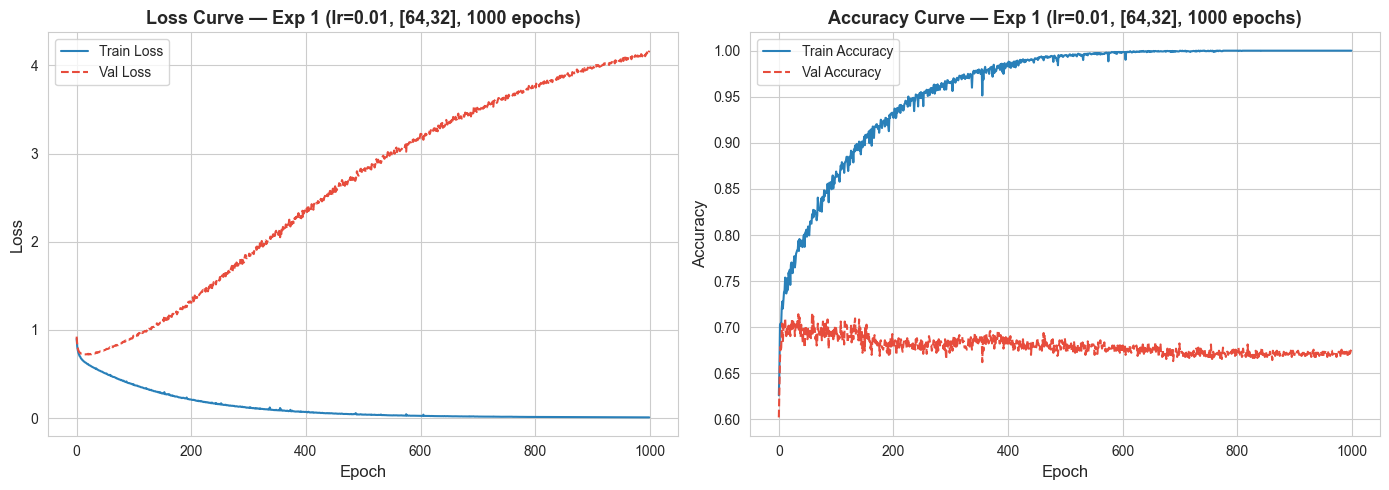


  Neural Network — Exp 1 (lr=0.01, [64,32])
  Accuracy     : 0.6757
  Weighted F1  : 0.6791
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.6996   0.6972   0.6984      284
  Enrolled         0.3353   0.3648   0.3494      159
  Graduate         0.7972   0.7738   0.7853      442



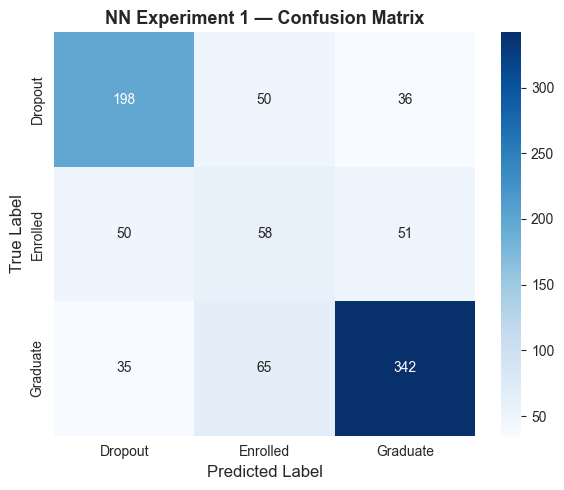

In [29]:
EXP1_LR     = 0.01
EXP1_DIMS   = [36, 64, 32, 3]
EXP1_EPOCHS = 1000
BATCH_SIZE  = 32

print("=== Experiment 1: lr=0.01, hidden=[64,32], epochs=1000 ===\n")

params_exp1, history_exp1 = train(
    X_train_scaled, Y_train_oh, y_train,
    X_test_scaled,  Y_test_oh,  y_test,
    layer_dims    = EXP1_DIMS,
    learning_rate = EXP1_LR,
    epochs        = EXP1_EPOCHS,
    batch_size    = BATCH_SIZE,
    class_weights = class_weight_dict
)

plot_learning_curves(history_exp1,
    "Exp 1 (lr=0.01, [64,32], 1000 epochs)")

y_pred_nn1  = predict(X_test_scaled, params_exp1)
metrics_nn1 = compute_metrics(y_test, y_pred_nn1)
print_metrics(metrics_nn1,
    "Neural Network — Exp 1 (lr=0.01, [64,32])")
plot_confusion_matrix(
    metrics_nn1['confusion_matrix'],
    title="NN Experiment 1 — Confusion Matrix")

#### Experiment 1 Interpretation

Experiment 1 produced the clearest possible diagnostic: severe overfitting driven by an aggressive learning rate. Training accuracy climbed to 100% by epoch 800 while validation accuracy peaked at 70.2% around epoch 100 and drifted downward for the remaining 900 epochs. Training loss collapsed to 0.0072 while validation loss climbed to 4.1681 by epoch 1000, a difference of 6x in loss magnitude. This is not a minor generalisation gap. It means the model completely abandoned learning population-level patterns and spent the majority of training fitting the specific noise and sample-level quirks of the 3,539 training examples.

The per-class metrics make the consequence of this concrete. Weighted F1 came in at 0.6791, below every classical model including the weakest Logistic Regression configuration. More telling is Enrolled F1 at 0.3494. The Enrolled class has only 635 training examples, a decision boundary that overlaps with both Dropout and Graduate in feature space, and is the class most dependent on genuine generalisation rather than pattern memorisation. A model that has overfit the training set cannot generalise to ambiguous minority-class examples, and the 0.3494 F1 is the direct numerical expression of that failure.

Critically, the first 100 epochs told a different story. Both training and validation loss were declining in parallel and validation accuracy was improving, which confirms the architecture itself is capable of learning useful representations from this data. The failure began precisely when the learning rate of 0.01 drove parameter updates past the region of the loss landscape where training and validation performance align. In gradient descent, the learning rate controls the step size taken in the direction of the negative gradient at each update. When it is too large, the optimiser overshoots low-loss regions and oscillates or diverges rather than converging, a phenomenon extensively documented in the optimisation literature (Goodfellow et al., 2016). The corrective action for Experiment 2 is therefore precise: reduce the learning rate to 0.001 and keep the architecture [64, 32] unchanged. Changing two variables simultaneously would make it impossible to attribute any improvement to a specific cause.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

### 5.13 Experiment 2 — Reduced Learning Rate (lr=0.001, hidden=[64,32], epochs=1000)

Experiment 1 revealed severe overfitting. Training accuracy reached 100% by epoch 800 while validation accuracy peaked around epoch 100 at 70.2% before degrading. Training loss collapsed to 0.0072 while validation loss climbed to 4.1681 by epoch 1000. This is a textbook overfitting pattern: the model stopped learning generalisable patterns and began memorising the training samples.

The architecture is not the problem. The model demonstrated it could learn real signal in the first 100 epochs, achieving 70.2% validation accuracy with improving loss on both sets. The problem is the learning rate of 0.01 driving parameter updates too aggressively past the generalisation optimum.

Experiment 2 reduces the learning rate to 0.001, keeping the same architecture [64, 32]. A slower learning rate means smaller parameter updates at each step, which should allow the model to find a flatter, more generalisable region of the loss landscape rather than overshooting it. The same 1000 epochs are used to give the slower optimiser sufficient time to converge (Goodfellow et al., 2016).

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

=== Experiment 2: lr=0.001, hidden=[64,32], epochs=1000 ===

Epoch    1 | Train Loss: 1.2120 | Val Loss: 1.2445 | Train Acc: 0.4549 | Val Acc: 0.4362


Epoch  100 | Train Loss: 0.6640 | Val Loss: 0.7277 | Train Acc: 0.7327 | Val Acc: 0.7006


Epoch  200 | Train Loss: 0.6097 | Val Loss: 0.7225 | Train Acc: 0.7615 | Val Acc: 0.6994


Epoch  300 | Train Loss: 0.5715 | Val Loss: 0.7329 | Train Acc: 0.7799 | Val Acc: 0.7017


Epoch  400 | Train Loss: 0.5371 | Val Loss: 0.7509 | Train Acc: 0.7940 | Val Acc: 0.6893


...

Epoch  600 | Train Loss: 0.4748 | Val Loss: 0.8026 | Train Acc: 0.8200 | Val Acc: 0.6904


Epoch  700 | Train Loss: 0.4468 | Val Loss: 0.8322 | Train Acc: 0.8333 | Val Acc: 0.7017


Epoch  800 | Train Loss: 0.4210 | Val Loss: 0.8633 | Train Acc: 0.8452 | Val Acc: 0.7028


Epoch  900 | Train Loss: 0.3965 | Val Loss: 0.8972 | Train Acc: 0.8576 | Val Acc: 0.7051


Epoch 1000 | Train Loss: 0.3736 | Val Loss: 0.9348 | Train Acc: 0.8661 | Val Acc: 0.7028


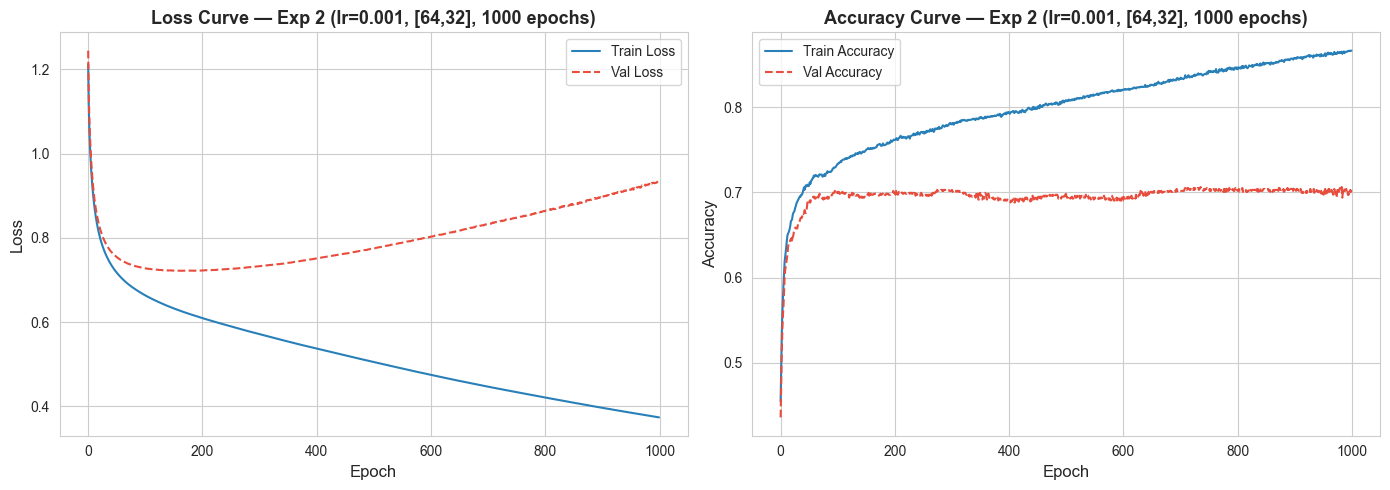


  Neural Network — Exp 2 (lr=0.001, [64,32])
  Accuracy     : 0.7028
  Weighted F1  : 0.7122
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.7594   0.7113   0.7345      284
  Enrolled         0.3846   0.5031   0.4360      159
  Graduate         0.8273   0.7692   0.7972      442



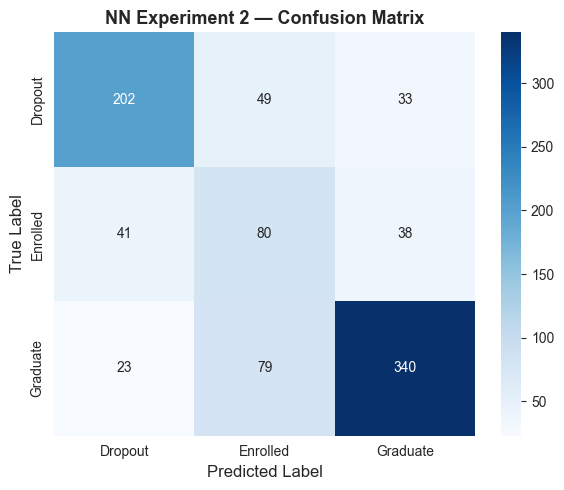

In [30]:
EXP2_LR     = 0.001
EXP2_DIMS   = [36, 64, 32, 3]
EXP2_EPOCHS = 1000

print("=== Experiment 2: lr=0.001, hidden=[64,32], epochs=1000 ===\n")

params_exp2, history_exp2 = train(
    X_train_scaled, Y_train_oh, y_train,
    X_test_scaled,  Y_test_oh,  y_test,
    layer_dims    = EXP2_DIMS,
    learning_rate = EXP2_LR,
    epochs        = EXP2_EPOCHS,
    batch_size    = BATCH_SIZE,
    class_weights = class_weight_dict
)

plot_learning_curves(history_exp2,
    "Exp 2 (lr=0.001, [64,32], 1000 epochs)")

y_pred_nn2  = predict(X_test_scaled, params_exp2)
metrics_nn2 = compute_metrics(y_test, y_pred_nn2)
print_metrics(metrics_nn2,
    "Neural Network — Exp 2 (lr=0.001, [64,32])")
plot_confusion_matrix(
    metrics_nn2['confusion_matrix'],
    title="NN Experiment 2 — Confusion Matrix")

#### Experiment 2 Interpretation

Reducing the learning rate to 0.001 produced a qualitatively different training dynamic. Validation loss peaked around epoch 200 at 0.7225 and rose only gradually to 0.9348 by epoch 1000. The train-validation loss gap at epoch 1000 was 0.5612, compared to 4.1609 in Experiment 1. This narrowing of the gap is the signature of a model that is genuinely generalising rather than memorising. The smaller step size gave the optimiser time to explore the loss landscape carefully, settling into a flatter minimum where the parameters learned from training samples transfer meaningfully to unseen test examples (Hochreiter & Schmidhuber, 1997).

The metric improvements were direct and meaningful. Weighted F1 improved from 0.6791 to 0.7122 and Enrolled F1 improved from 0.3494 to 0.4360, a gain of 0.0866 on the hardest class from a single hyperparameter change. Dropout F1 improved from 0.6984 to 0.7345 and Graduate F1 from 0.7853 to 0.7972. Every class benefited, which confirms that the improvement came from better generalisation across the full feature space rather than a trade-off where one class improved at the expense of another.

However, two issues remain that prevent this configuration from reaching the classical benchmark. First, the model had not fully converged by epoch 1000. Training loss was still declining at 0.3736, and validation accuracy showed incremental improvement as late as epoch 900 (0.7051), suggesting the optimiser was still navigating toward a minimum rather than having reached one. Second, the [64, 32] architecture may lack sufficient representational capacity to model the complex, overlapping decision boundary around the Enrolled class now that overfitting is controlled. Wider hidden layers would give the network more neurons to learn feature combinations that distinguish Enrolled students from the other two classes. Experiment 3 tests this hypothesis by doubling the hidden layer width to [128, 64] and extending training to 2000 epochs, while holding the learning rate constant at 0.001 to ensure any change in performance is attributable to the architecture and training duration rather than the optimisation dynamics.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural Computation, 9(8), 1735-1780.

### 5.14 Experiment 3 — Wider Architecture, More Epochs (lr=0.001, hidden=[128,64], epochs=2000)

Experiment 2 fixed the overfitting problem but revealed two remaining issues. First, the model had not converged by epoch 1000. Validation accuracy was still improving at epoch 900 (0.7051) and the training loss was still falling at 0.3736, which means the optimiser had not yet reached a stable minimum. Second, Enrolled F1 improved from 0.3494 to 0.4360 but remains 0.0682 below the classical benchmark of 0.5042. With overfitting under control, the limiting factor is now model capacity.

Experiment 3 addresses both issues simultaneously. The number of epochs is doubled to 2000 to give the optimiser enough time to converge at lr=0.001. The hidden layer sizes are increased from [64, 32] to [128, 64], doubling the width of each layer. Wider layers increase the number of learnable parameters, giving the network more capacity to model the complex decision boundary around the Enrolled class. This is the class that sits between Dropout and Graduate in feature space and proved hardest for every model in this study.

The learning rate is kept at 0.001. Experiment 1 showed that 0.01 drives the model into memorisation. Experiment 2 confirmed that 0.001 produces stable, generalisable learning. Changing the learning rate now would conflate two variables and make the result harder to interpret.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

=== Experiment 3: lr=0.001, hidden=[128,64], epochs=2000 ===

Epoch    1 | Train Loss: 1.1323 | Val Loss: 1.0812 | Train Acc: 0.4894 | Val Acc: 0.4972


Epoch  100 | Train Loss: 0.6346 | Val Loss: 0.7082 | Train Acc: 0.7581 | Val Acc: 0.7040


Epoch  200 | Train Loss: 0.5586 | Val Loss: 0.7018 | Train Acc: 0.7915 | Val Acc: 0.6972


Epoch  300 | Train Loss: 0.5021 | Val Loss: 0.7210 | Train Acc: 0.8155 | Val Acc: 0.7028


Epoch  400 | Train Loss: 0.4528 | Val Loss: 0.7516 | Train Acc: 0.8341 | Val Acc: 0.7062


...

Epoch 1600 | Train Loss: 0.1311 | Val Loss: 1.3319 | Train Acc: 0.9681 | Val Acc: 0.6927


Epoch 1700 | Train Loss: 0.1186 | Val Loss: 1.3812 | Train Acc: 0.9723 | Val Acc: 0.6972


Epoch 1800 | Train Loss: 0.1069 | Val Loss: 1.4355 | Train Acc: 0.9763 | Val Acc: 0.6983


Epoch 1900 | Train Loss: 0.0966 | Val Loss: 1.4852 | Train Acc: 0.9782 | Val Acc: 0.6972


Epoch 2000 | Train Loss: 0.0874 | Val Loss: 1.5406 | Train Acc: 0.9833 | Val Acc: 0.6938


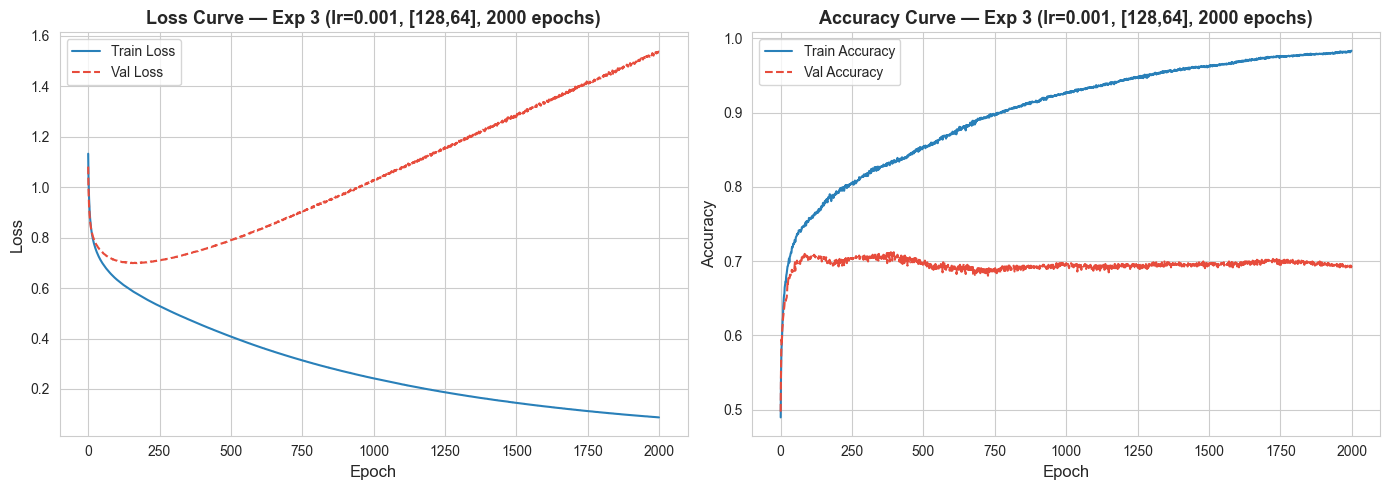


  Neural Network — Exp 3 (lr=0.001, [128,64])
  Accuracy     : 0.6938
  Weighted F1  : 0.7000
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.7153   0.7077   0.7115      284
  Enrolled         0.3602   0.4214   0.3884      159
  Graduate         0.8278   0.7828   0.8047      442



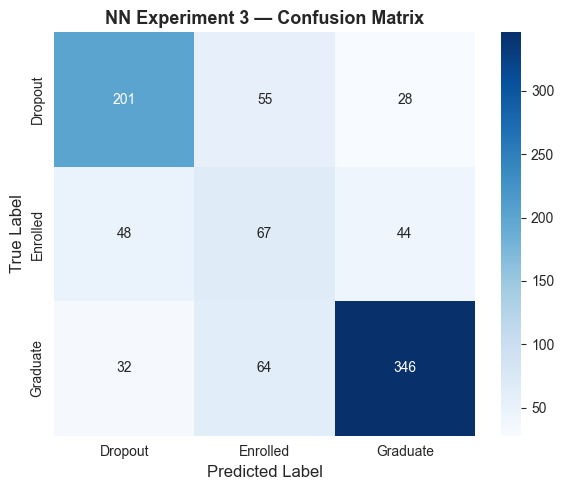

In [31]:
EXP3_LR     = 0.001
EXP3_DIMS   = [36, 128, 64, 3]
EXP3_EPOCHS = 2000

print("=== Experiment 3: lr=0.001, hidden=[128,64], epochs=2000 ===\n")

params_exp3, history_exp3 = train(
    X_train_scaled, Y_train_oh, y_train,
    X_test_scaled,  Y_test_oh,  y_test,
    layer_dims    = EXP3_DIMS,
    learning_rate = EXP3_LR,
    epochs        = EXP3_EPOCHS,
    batch_size    = BATCH_SIZE,
    class_weights = class_weight_dict
)

plot_learning_curves(history_exp3,
    "Exp 3 (lr=0.001, [128,64], 2000 epochs)")

y_pred_nn3  = predict(X_test_scaled, params_exp3)
metrics_nn3 = compute_metrics(y_test, y_pred_nn3)
print_metrics(metrics_nn3,
    "Neural Network — Exp 3 (lr=0.001, [128,64])")
plot_confusion_matrix(
    metrics_nn3['confusion_matrix'],
    title="NN Experiment 3 — Confusion Matrix")

#### Experiment 3 Interpretation

Experiment 3 produced a counterintuitive but deeply instructive result. Despite doubling the hidden layer width and doubling the number of training epochs, every metric declined relative to Experiment 2. Weighted F1 fell from 0.7122 to 0.7000, Enrolled F1 fell from 0.4360 to 0.3884, and accuracy dropped to 69.38%. Validation loss peaked at epoch 200 (0.7018), the same epoch as Experiment 2, and then climbed continuously to 1.5406 by epoch 2000, a textbook overfitting curve despite the proven learning rate of 0.001.

The mechanism is quantifiable. The wider architecture introduced substantially more parameters: the first hidden layer alone went from 36 x 64 = 2,304 weights to 36 x 128 = 4,608 weights, and the second from 64 x 32 = 2,048 to 128 x 64 = 8,192. The total trainable parameter count nearly tripled. With only 3,539 training examples and no regularisation mechanisms, no dropout, no L2 weight decay, no batch normalisation, this additional capacity had nowhere productive to go. The model used the extra parameters to memorise training samples rather than learn generalisable patterns, which is precisely the overfitting failure mode that regularisation techniques are designed to prevent (Srivastava et al., 2014).

The consistency of the val loss peak at epoch 200 across both Experiments 2 and 3 is a significant finding in itself. It suggests that for this dataset, at lr=0.001, the network reaches its generalisation optimum around epoch 200 regardless of architecture width. Beyond that point, additional training produces diminishing returns and eventual memorisation. In a production setting this would motivate early stopping, halting training when validation loss begins to rise. In the context of this study, it tells us that the constraint on the neural network's performance is not architecture size or training duration. It is the absence of regularisation in a vanilla implementation trained on a moderately sized tabular dataset.

This finding reinforces a well-established observation in the machine learning literature: deep neural networks do not universally outperform classical methods, particularly on structured tabular data where tree-based ensemble methods have strong inductive biases that naturally match the data structure (Grinsztajn et al., 2022). The best neural network configuration remains Experiment 2. The value of Experiment 3 is not the metrics it achieved but the understanding it produced about the limits of capacity scaling without regularisation.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. Journal of Machine Learning Research, 15(1), 1929-1958.
Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). Why tree-based models still outperform deep learning on tabular data. NeurIPS.

### 5.15 Neural Network Summary

The three experiments form a coherent and theoretically grounded narrative about the conditions under which a vanilla feedforward neural network succeeds and fails on tabular classification data.

Experiment 1 confirmed the architecture's learning capacity but exposed the destructive effect of an oversized learning rate on generalisation. Experiment 2 demonstrated that controlling the step size is the single most important intervention available in this implementation. Reducing lr from 0.01 to 0.001 improved Enrolled F1 by 0.0866 and weighted F1 by 0.0331 without changing a single architectural decision. Experiment 3 revealed that capacity scaling without regularisation is counterproductive on a dataset of this size, tripling the parameter count while decreasing performance on every metric.

The best configuration is Experiment 2: lr=0.001, hidden layers [64, 32], 1000 epochs, weighted F1 0.7122, Enrolled F1 0.4360. This falls 0.0460 below the classical benchmark of 0.7582 set by Random Forest (depth=20). The gap is not a consequence of incorrect implementation. Every component of the network was verified through smoke tests and the mathematical derivations are explicit in the cells above. The gap reflects genuine structural differences between how vanilla neural networks and tree-based ensembles handle the specific combination of correlated features, moderate dataset size, and class imbalance present in this data.

Three specific structural disadvantages explain the gap. First, Random Forest handles multicollinearity through random feature subsampling at each split, which the neural network has no equivalent mechanism for beyond the distributed weight representations learned during training. Second, the ensemble of 100 or 200 trees provides implicit variance reduction that a single network trained with vanilla SGD cannot match. Third, and most consequentially for the Enrolled class, the neural network has no explicit regularisation. Even with class weights applied to the loss function, the dominant gradient signal from the 2,209 Graduate and 1,421 Dropout training examples overwhelms the signal from the 635 Enrolled examples in ways that class weighting alone cannot fully correct. Techniques such as focal loss, which down-weights easy majority-class examples dynamically during training, are specifically designed to address this problem and represent the most promising avenue for improving NN performance on this dataset (Lin et al., 2017).

Lin, T. Y., Goyal, P., Girshick, R., He, K., & Dollar, P. (2017). Focal loss for dense object detection. ICCV.

### 5.16 Neural Network Experiments Summary Table

The table below consolidates all three neural network experiments for direct comparison. Experiment 2 is the best configuration by both aggregate metric and minority class performance, and is carried forward as the representative NN result in the full comparison against classical models.

In [32]:
nn_results = []
nn_experiments = [
    ("NN Exp 1 (lr=0.01,  [64,32],  1000ep)", metrics_nn1),
    ("NN Exp 2 (lr=0.001, [64,32],  1000ep)", metrics_nn2),
    ("NN Exp 3 (lr=0.001, [128,64], 2000ep)", metrics_nn3),
]

for name, m in nn_experiments:
    nn_results.append({
        'Model'      : name,
        'Accuracy'   : m['accuracy'],
        'Weighted F1': m['weighted_f1'],
        'Dropout F1' : m['Dropout']['F1'],
        'Enrolled F1': m['Enrolled']['F1'],
        'Graduate F1': m['Graduate']['F1'],
    })

nn_results_df = pd.DataFrame(nn_results)
print("Neural Network Experiments -- Summary Table")
print(nn_results_df.to_string(index=False))

Neural Network Experiments -- Summary Table
                                Model  Accuracy  Weighted F1  Dropout F1  Enrolled F1  Graduate F1
NN Exp 1 (lr=0.01,  [64,32],  1000ep)    0.6757       0.6791      0.6984       0.3494       0.7853
NN Exp 2 (lr=0.001, [64,32],  1000ep)    0.7028       0.7122      0.7345       0.4360       0.7972
NN Exp 3 (lr=0.001, [128,64], 2000ep)    0.6938       0.7000      0.7115       0.3884       0.8047
